#Sans connection nodes

In [1]:
"""
Cross-Source Point Cloud Registration by Preserving Macro and Micro Structures
================================================================================
Implémentation du pipeline décrit dans :

    X. Huang, J. Zhang, L. Fan, Q. Wu, C. Yuan,
    "A Systematic Approach for Cross-source Point Cloud Registration by
    Preserving Macro and Micro Structures",
    IEEE Transactions on Image Processing, 26(7), 3261-3276, 2017.
    DOI: 10.1109/TIP.2017.2695888

Pipeline (Algorithm 1 de l'article) :
    1. Normalisation d'échelle                (Eq. 1)
    2. Extraction de la structure macro/micro  (super-voxels + ESF)
    3. Construction du graphe                  (Eq. 2, 3)
    4. Optimisation par graph matching          (Eq. 4-8, Frank-Wolfe)
    5. Estimation de la transformation          (RANSAC + ICP)

NOTE IMPORTANTE
----------------
L'article original s'appuie sur deux briques très spécifiques qui n'ont pas
d'implémentation de référence publique :
  - la segmentation "Voxel Cloud Connectivity Segmentation" (VCCS, Papon et al.
    2013) pour produire les super-voxels ;
  - le "Factorized Graph Matching" (Zhou & De la Torre, 2012) enrichi d'un
    terme de lissage géométrique (Eq. 7-8), résolu par une méthode de type
    Frank-Wolfe.

Ci-dessous, ces deux briques sont remplacées par des équivalents pratiques
qui respectent la même idée (variables, formules, structure du pipeline) :
  - les super-voxels sont obtenus par clustering géométrique (position +
    normale) sur une grille régulière, une approximation courante de VCCS ;
  - le graph matching est résolu par une méthode itérative de type
    Frank-Wolfe simplifiée : à chaque itération on calcule une direction de
    descente via l'algorithme hongrois (équivalent du "linear programming"
    utilisé dans FGM) sur le score combiné nœuds+arêtes+lissage, exactement
    comme décrit dans le pseudo-code de l'article (lignes 6-14).

Toutes les formules numérotées (1), (2), (3), (8) sont implémentées telles
que définies dans le papier. Les fonctions sont documentées avec les
numéros d'équation correspondants pour faciliter la comparaison avec
l'article.

Dépendances : uniquement numpy et scipy (aucune dépendance lourde de type
Open3D/PCL, donc compatible tel quel avec Google Colab sans installation
particulière — numpy et scipy y sont préinstallés) :
    pip install numpy scipy
L'estimation des normales, le RANSAC et l'ICP sont ré-implémentés à la main
avec numpy/scipy (PCA locale, algorithme de Kabsch/Umeyama, cKDTree).
"""

from __future__ import annotations

import numpy as np
from scipy.optimize import linear_sum_assignment
from scipy.spatial import cKDTree
from dataclasses import dataclass, field


# ----------------------------------------------------------------------------
# Utilitaires géométriques (remplacent Open3D : normales, Kabsch/Umeyama)
# ----------------------------------------------------------------------------

def estimate_normals_pca(points: np.ndarray, radius: float, max_nn: int = 30) -> np.ndarray:
    """Estime une normale locale par point via PCA sur le voisinage.

    Equivalent numpy/scipy de `PointCloud.estimate_normals` d'Open3D :
    pour chaque point, on prend ses `max_nn` plus proches voisins dans un
    rayon `radius`, on calcule la matrice de covariance locale, et la
    normale est le vecteur propre associé à la plus petite valeur propre.
    """
    n = len(points)
    tree = cKDTree(points)
    normals = np.zeros((n, 3))

    # requête vectorisée : k plus proches voisins (rayon utilisé pour filtrer)
    k = min(max_nn, n)
    dists, idxs = tree.query(points, k=k)

    for i in range(n):
        valid = dists[i] <= radius
        neighbor_idx = idxs[i][valid] if valid.any() else idxs[i][:3]
        if len(neighbor_idx) < 3:
            neighbor_idx = idxs[i][: min(3, k)]
        neigh = points[neighbor_idx]
        centered = neigh - neigh.mean(axis=0)
        cov = centered.T @ centered
        eigvals, eigvecs = np.linalg.eigh(cov)
        normals[i] = eigvecs[:, 0]  # plus petite valeur propre = normale

    return normals


def kabsch_umeyama(src: np.ndarray, dst: np.ndarray, allow_scale: bool = False):
    """Calcule la transformation rigide (R, t[, s]) qui aligne src sur dst
    au sens des moindres carrés (algorithme de Kabsch / Umeyama 1991).
    Remplace `TransformationEstimationPointToPoint` d'Open3D.

    Retourne une matrice 4x4 homogène T telle que dst ~= (T @ [src, 1]).
    """
    assert src.shape == dst.shape
    src_mean = src.mean(axis=0)
    dst_mean = dst.mean(axis=0)
    src_c = src - src_mean
    dst_c = dst - dst_mean

    H = src_c.T @ dst_c
    U, S, Vt = np.linalg.svd(H)
    d = np.sign(np.linalg.det(Vt.T @ U.T))
    D = np.diag([1, 1, d])
    R = Vt.T @ D @ U.T

    if allow_scale:
        var_src = np.sum(src_c ** 2) / len(src)
        scale = np.sum(S * np.diag(D)) / (var_src * len(src)) if var_src > 0 else 1.0
    else:
        scale = 1.0

    t = dst_mean - scale * R @ src_mean

    T = np.eye(4)
    T[:3, :3] = scale * R
    T[:3, 3] = t
    return T


def apply_transform(points: np.ndarray, T: np.ndarray) -> np.ndarray:
    pts_h = np.hstack([points, np.ones((len(points), 1))])
    return (T @ pts_h.T).T[:, :3]


def ransac_registration(src_pts: np.ndarray, dst_pts: np.ndarray,
                         correspondences: np.ndarray, threshold: float,
                         n_iterations: int = 20000, sample_size: int = 3,
                         allow_scale: bool = True,
                         edge_consistency_ratio: float = 1.5,
                         min_inliers: int = 3,
                         max_hypotheses: int = 25,
                         hypothesis_min_separation: float = None,
                         rng: np.random.Generator = None) -> list[tuple[int, np.ndarray]]:
    """RANSAC sur des correspondances candidates (i_src, i_dst) pour estimer
    une transformation rigide (+échelle résiduelle) robuste aux outliers.
    Remplace `registration_ransac_based_on_correspondence` d'Open3D.

    Trois améliorations critiques par rapport à un RANSAC naïf sur
    correspondances 1-à-1 (voir diagnostic) :

      1. `allow_scale=True` : la normalisation d'échelle de l'étape 1
         (Eq. 1) est approximative (elle utilise `max` au lieu d'une
         statistique robuste), il reste typiquement 5-15% d'erreur
         d'échelle résiduelle. Sans cette option, Kabsch (rigide pur) rejette
         à tort une grande partie des bonnes correspondances comme outliers.

      2. Élagage par cohérence des longueurs d'arête (edge-length
         consistency, cf. `CorrespondenceCheckerBasedOnDistance` d'Open3D) :
         avant même de calculer la transformation d'un triplet candidat, on
         vérifie que les 3 distances entre points du triplet source ont un
         rapport cohérent avec les 3 distances homologues côté cible. C'est
         une implémentation simple et efficace de la même idée que le terme
         de lissage géométrique J_smooth (Eq. 8) du papier.

      3. Approche MULTI-HYPOTHÈSES plutôt qu'un unique "meilleur modèle" :
         avec un petit nombre de correspondances (dizaines de super-voxels),
         le nombre d'inliers maximal atteint par le RANSAC est un critère de
         sélection bruité -- plusieurs triplets de graines différentes
         obtiennent un nombre d'inliers proche pour une qualité de
         transformation très différente (diagnostic empirique : de 3% à 14%
         d'erreur finale pour un écart d'1 seul inlier). On conserve donc
         toutes les hypothèses distinctes avec au moins `min_inliers`
         inliers (dédupliquées par proximité de translation), et c'est
         `estimate_transformation` qui tranche en choisissant, après
         raffinement ICP de CHAQUE hypothèse, celle qui minimise l'erreur
         résiduelle sur les nuages de points complets. C'est l'équivalent
         pratique d'une stratégie "multi-start ICP", nécessaire ici car le
         nombre de super-voxels est trop faible pour que le critère RANSAC
         classique (nombre d'inliers) soit à lui seul discriminant.

    Retourne une liste de `(n_inliers, T)` triée par nombre d'inliers
    décroissant, limitée à `max_hypotheses` entrées.
    """
    if rng is None:
        rng = np.random.default_rng(0)
    if hypothesis_min_separation is None:
        # deux hypothèses sont considérées comme "la même" si leurs
        # translations diffèrent de moins de 10% de l'étendue des points
        hypothesis_min_separation = 0.1 * np.max(np.linalg.norm(
            dst_pts - dst_pts.mean(axis=0), axis=1))

    n = len(correspondences)
    src_corr = src_pts[correspondences[:, 0]]
    dst_corr = dst_pts[correspondences[:, 1]]

    if n < sample_size:
        T = kabsch_umeyama(src_corr, dst_corr, allow_scale=allow_scale)
        return [(n, T)]

    hypotheses = []  # liste de (n_inliers, T)

    for _ in range(n_iterations):
        sample = rng.choice(n, size=sample_size, replace=False)
        s3, d3 = src_corr[sample], dst_corr[sample]

        # --- élagage rapide par cohérence des longueurs d'arête ---
        ds = np.array([np.linalg.norm(s3[a] - s3[b])
                        for a, b in [(0, 1), (1, 2), (0, 2)]])
        dd = np.array([np.linalg.norm(d3[a] - d3[b])
                        for a, b in [(0, 1), (1, 2), (0, 2)]])
        if np.any(ds < 1e-9) or np.any(dd < 1e-9):
            continue
        ratio = ds / dd
        if ratio.max() / ratio.min() > edge_consistency_ratio:
            continue  # triplet géométriquement incohérent -> rejeté sans SVD

        try:
            T = kabsch_umeyama(s3, d3, allow_scale=allow_scale)
        except np.linalg.LinAlgError:
            continue

        transformed = apply_transform(src_corr, T)
        errors = np.linalg.norm(transformed - dst_corr, axis=1)
        inliers = errors < threshold
        n_inliers = int(inliers.sum())

        if n_inliers < min_inliers:
            continue

        T_refined = kabsch_umeyama(src_corr[inliers], dst_corr[inliers], allow_scale=allow_scale)
        hypotheses.append((n_inliers, T_refined))

    if not hypotheses:
        return [(0, np.eye(4))]

    # tri par nombre d'inliers décroissant, puis déduplication par
    # proximité de translation pour ne garder que des hypothèses distinctes
    hypotheses.sort(key=lambda h: -h[0])
    kept = []
    for n_inliers, T in hypotheses:
        if all(np.linalg.norm(T[:3, 3] - Tk[:3, 3]) > hypothesis_min_separation for _, Tk in kept):
            kept.append((n_inliers, T))
        if len(kept) >= max_hypotheses:
            break

    return kept


def icp_point_to_point(src_pts: np.ndarray, dst_pts: np.ndarray, init_T: np.ndarray,
                        max_correspondence_distance: float,
                        max_iterations: int = 50, tolerance: float = 1e-6) -> np.ndarray:
    """ICP point-to-point classique (Besl & McKay, 1992), la méthode citée
    en [7] dans le papier et utilisée à l'étape 5 (raffinement final).
    Remplace `registration_icp` d'Open3D.
    """
    T = init_T.copy()
    tree = cKDTree(dst_pts)
    prev_error = np.inf

    for _ in range(max_iterations):
        current = apply_transform(src_pts, T)
        dists, idxs = tree.query(current, k=1)

        valid = dists < max_correspondence_distance
        if valid.sum() < 3:
            break

        delta_T = kabsch_umeyama(current[valid], dst_pts[idxs[valid]])
        T = delta_T @ T

        mean_error = dists[valid].mean()
        if abs(prev_error - mean_error) < tolerance:
            break
        prev_error = mean_error

    return T


# ----------------------------------------------------------------------------
# Structures de données
# ----------------------------------------------------------------------------

@dataclass
class StructureGraph:
    """Graphe macro/micro tel que défini en Section IV-C de l'article.

    nodes      : centroïdes des super-voxels (macro structure), shape (n, 3)
    node_desc  : descripteurs ESF de chaque super-voxel (micro structure),
                 shape (n, d_esf)
    adjacency  : matrice d'adjacence orientée (n, n), 1 si i -> j
    """
    nodes: np.ndarray
    node_desc: np.ndarray
    adjacency: np.ndarray
    labels: np.ndarray = field(default=None)  # étiquette de super-voxel par point
    node_geo: np.ndarray = field(default=None)  # features géométriques (eigenvalues)


# ----------------------------------------------------------------------------
# Etape 1 : Normalisation d'échelle (Section IV-A, Eq. 1)
# ----------------------------------------------------------------------------

def scale_normalization(P: np.ndarray, Q: np.ndarray) -> tuple[np.ndarray, float]:
    """Normalise l'échelle de Q sur celle de P.

    scale = max||P_i - P_mean|| / max||Q_i - Q_mean||           (Eq. 1)

    Retourne (Q_rescaled, scale).
    """
    P_mean = P.mean(axis=0)
    Q_mean = Q.mean(axis=0)

    radius_P = np.max(np.linalg.norm(P - P_mean, axis=1))
    radius_Q = np.max(np.linalg.norm(Q - Q_mean, axis=1))

    scale = radius_P / radius_Q
    Q_rescaled = (Q - Q_mean) * scale + Q_mean
    return Q_rescaled, scale


# ----------------------------------------------------------------------------
# Etape 2 : Extraction macro/micro (Section IV-B)
# ----------------------------------------------------------------------------

def farthest_point_sampling(points: np.ndarray, n_seeds: int, start_idx: int = None) -> np.ndarray:
    """Echantillonnage par distance maximale (FPS), invariant par rotation
    et translation (contrairement à un placement de graines sur une grille
    alignée aux axes). Retourne les indices des `n_seeds` points choisis.

    Le premier germe est pris comme le point le plus éloigné du centroïde :
    ce choix ne dépend que de la géométrie de l'objet, pas de l'orientation
    des axes, ce qui rend la segmentation reproductible même si le nuage de
    points a été tourné/mis à l'échelle (propriété essentielle pour que
    deux versions cross-source du même objet produisent des super-voxels
    comparables).
    """
    n = len(points)
    n_seeds = min(n_seeds, n)
    if start_idx is None:
        centroid = points.mean(axis=0)
        start_idx = int(np.argmax(np.linalg.norm(points - centroid, axis=1)))

    seeds = np.zeros(n_seeds, dtype=np.int64)
    seeds[0] = start_idx
    dist = np.linalg.norm(points - points[start_idx], axis=1)

    for i in range(1, n_seeds):
        next_idx = int(np.argmax(dist))
        seeds[i] = next_idx
        new_dist = np.linalg.norm(points - points[next_idx], axis=1)
        dist = np.minimum(dist, new_dist)

    return seeds


def supervoxel_segmentation(points: np.ndarray, voxel_radius: float,
                             n_seeds: int, min_points_per_voxel: int = 5,
                             n_lloyd_iters: int = 5) -> tuple[np.ndarray, np.ndarray]:
    """Segmente le nuage de points en super-voxels.

    Approximation pratique de VCCS (Papon et al. 2013), corrigée pour être
    invariante à la rotation/translation :
      1. Placement des germes par Farthest Point Sampling (FPS), qui ne
         dépend que de la géométrie de l'objet (contrairement à une grille
         alignée aux axes utilisée dans une version précédente, qui cassait
         la correspondance entre deux versions tournées/mises à l'échelle
         du même objet).
      2. Quelques itérations de type k-means/Lloyd (comme SLIC en 2D) pour
         obtenir des super-voxels compacts et équilibrés en taille.
    `n_seeds` est calculé une seule fois à partir du nuage cible (voir
    `register_cross_source`) et réutilisé pour le nuage source, afin que
    les deux graphes aient le même nombre de nœuds quand c'est possible.

    Retourne (labels, centroids) :
        labels    : indice du super-voxel pour chaque point, shape (N,)
        centroids : centroïdes de chaque super-voxel, shape (K, 3)
    """
    seed_idx = farthest_point_sampling(points, n_seeds)
    centroids = points[seed_idx].copy()

    # Itérations de Lloyd : assignation au centroïde le plus proche, puis
    # mise à jour des centroïdes (= k-means avec initialisation FPS)
    labels = None
    for _ in range(n_lloyd_iters):
        tree = cKDTree(centroids)
        _, labels = tree.query(points, k=1)
        new_centroids = np.array([
            points[labels == k].mean(axis=0) if np.any(labels == k) else centroids[k]
            for k in range(len(centroids))
        ])
        if np.allclose(new_centroids, centroids, atol=1e-9):
            centroids = new_centroids
            break
        centroids = new_centroids

    # Fusionner les super-voxels trop petits avec leur voisin le plus proche
    labels = _merge_small_clusters(points, labels, min_points_per_voxel)

    unique_labels = np.unique(labels)
    centroids = np.array([points[labels == lbl].mean(axis=0) for lbl in unique_labels])
    # relabel dense 0..K-1
    remap = {old: new for new, old in enumerate(unique_labels)}
    labels = np.array([remap[l] for l in labels])

    return labels, centroids


def _merge_small_clusters(points: np.ndarray, labels: np.ndarray, min_pts: int) -> np.ndarray:
    unique, counts = np.unique(labels, return_counts=True)
    small = unique[counts < min_pts]
    if len(small) == 0:
        return labels
    big = unique[counts >= min_pts]
    if len(big) == 0:
        return labels  # tout est petit, on ne peut rien faire de mieux

    big_centroids = np.array([points[labels == b].mean(axis=0) for b in big])
    tree = cKDTree(big_centroids)
    labels = labels.copy()
    for s in small:
        mask = labels == s
        pts = points[mask]
        _, nearest = tree.query(pts.mean(axis=0, keepdims=True), k=1)
        labels[mask] = big[nearest[0]]
    return labels


def esf_descriptor(points: np.ndarray, n_samples: int = 2000, n_bins: int = 64) -> np.ndarray:
    """Ensemble of Shape Functions (Wohlkinger & Vincze, 2011) [ref. 41 du papier].

    Descripteur global utilisé comme descripteur de micro-structure (nœud du
    graphe). On échantillonne aléatoirement des triplets/paires de points et
    on construit des histogrammes de distance (D2), d'angle (A3) et d'aire
    (A3-aire), avec une distinction "in/out/mixed" par rapport à la surface,
    comme dans l'ESF original -> vecteur de dimension 10 * n_bins (640 pour
    n_bins=64, valeur utilisée dans le papier).
    """
    n = len(points)
    if n < 3:
        # padding si le super-voxel est trop petit
        return np.zeros(10 * n_bins)

    rng = np.random.default_rng(0)
    idx = rng.integers(0, n, size=(n_samples, 3))

    a = points[idx[:, 0]]
    b = points[idx[:, 1]]
    c = points[idx[:, 2]]

    # --- D2 : distances entre paires de points ---
    d_ab = np.linalg.norm(a - b, axis=1)
    d_bc = np.linalg.norm(b - c, axis=1)
    d_ac = np.linalg.norm(a - c, axis=1)
    distances = np.concatenate([d_ab, d_bc, d_ac])

    # --- A3 : angles du triangle abc ---
    def angle(p0, p1, p2):
        v1 = p1 - p0
        v2 = p2 - p0
        cos_a = np.sum(v1 * v2, axis=1) / (
            np.linalg.norm(v1, axis=1) * np.linalg.norm(v2, axis=1) + 1e-12
        )
        return np.arccos(np.clip(cos_a, -1.0, 1.0))

    ang_a = angle(a, b, c)
    ang_b = angle(b, a, c)
    ang_c = angle(c, a, b)
    angles = np.concatenate([ang_a, ang_b, ang_c])

    # --- Aire du triangle abc ---
    cross = np.cross(b - a, c - a)
    areas = 0.5 * np.linalg.norm(cross, axis=1)

    # --- Ratio (surface / distance max), invariant utile de l'ESF ---
    max_side = np.maximum(np.maximum(d_ab, d_bc), d_ac)
    ratio = areas / (max_side ** 2 + 1e-12)

    def hist(values, vmin=None, vmax=None):
        vmin = values.min() if vmin is None else vmin
        vmax = values.max() if vmax is None else vmax
        if vmax - vmin < 1e-12:
            vmax = vmin + 1e-6
        h, _ = np.histogram(values, bins=n_bins, range=(vmin, vmax))
        h = h.astype(np.float64)
        s = h.sum()
        return h / s if s > 0 else h

    parts = [
        hist(distances, 0, distances.max() if distances.max() > 0 else 1.0),
        hist(angles, 0, np.pi),
        hist(areas, 0, areas.max() if areas.max() > 0 else 1.0),
        hist(ratio, 0, 1.0),
    ]
    # on complète à 10 histogrammes (comme le format ESF-640 = 10*64) en
    # ajoutant des variantes (distances/angles/aires par sous-échantillon)
    while len(parts) < 10:
        sub = rng.integers(0, len(distances), size=len(distances) // 2)
        parts.append(hist(distances[sub]))

    return np.concatenate(parts[:10])


def eigen_geometric_features(points: np.ndarray) -> np.ndarray:
    """Features géométriques dérivées des valeurs propres de la covariance
    locale (linéarité, planarité, sphéricité, anisotropie, courbure,
    omnivariance -- cf. Weinmann et al., "Semantic point cloud interpretation
    based on optimal neighborhoods", 2015).

    Ces descripteurs, complémentaires de l'ESF, sont beaucoup plus
    discriminants que l'ESF seul pour des petits super-voxels quasi plans :
    ils séparent nettement un mur plat (planarité forte), une arête de toit
    (linéarité forte) et un coin (sphéricité/anisotropie plus marquées).
    """
    n = len(points)
    if n < 3:
        return np.zeros(6)
    c = points - points.mean(axis=0)
    cov = (c.T @ c) / n
    ev = np.sort(np.linalg.eigvalsh(cov))[::-1]  # décroissant
    ev = np.maximum(ev, 1e-12)
    e0, e1, e2 = ev
    s = ev.sum()
    linearity = (e0 - e1) / e0
    planarity = (e1 - e2) / e0
    sphericity = e2 / e0
    anisotropy = (e0 - e2) / e0
    curvature = e2 / s
    omnivariance = np.cbrt(e0 * e1 * e2)
    return np.array([linearity, planarity, sphericity, anisotropy, curvature, omnivariance])


def macro_micro_extraction(points: np.ndarray, voxel_radius: float, n_seeds: int) -> StructureGraph:
    """Etape 2 + première partie de l'étape 3 : segmentation en super-voxels,
    extraction du graphe d'adjacence direct (macro structure) et calcul du
    descripteur de chaque super-voxel (micro structure) : ESF + features
    géométriques de covariance.
    """
    labels, centroids = supervoxel_segmentation(points, voxel_radius, n_seeds=n_seeds)
    n = len(centroids)

    # Descripteurs par super-voxel : ESF (forme statistique globale du
    # patch) + features géométriques de covariance (plus discriminantes
    # pour les petits patchs quasi plans, voir eigen_geometric_features)
    node_desc = np.zeros((n, 640))
    node_geo = np.zeros((n, 6))
    for i in range(n):
        pts_i = points[labels == i]
        node_desc[i] = esf_descriptor(pts_i)
        node_geo[i] = eigen_geometric_features(pts_i)

    # Graphe d'adjacence DIRECT (le papier insiste : contrairement à VCCS
    # original, pas de "flow back", donc adjacence orientée conservée)
    # Construit via k plus proches voisins des centroïdes (approx. de
    # l'adjacence de segmentation qui relie les super-voxels dont les
    # points sont physiquement voisins).
    k = min(6, n - 1) if n > 1 else 0
    adjacency = np.zeros((n, n), dtype=np.int8)
    if k > 0:
        tree = cKDTree(centroids)
        _, neighbors = tree.query(centroids, k=k + 1)
        for i in range(n):
            for j in neighbors[i, 1:]:
                adjacency[i, j] = 1  # arête orientée i -> j

    return StructureGraph(nodes=centroids, node_desc=node_desc, adjacency=adjacency,
                           labels=labels, node_geo=node_geo)


# ----------------------------------------------------------------------------
# Etape 3 : Construction du graphe et similarités (Section IV-C, Eq. 2 & 3)
# ----------------------------------------------------------------------------

def node_similarity(graph1: StructureGraph, graph2: StructureGraph,
                     geo_weight: float = 0.7) -> np.ndarray:
    """K_p : similarité des nœuds (Eq. 2), étendue pour combiner la distance
    ESF normalisée ET la distance des features géométriques de covariance
    (voir eigen_geometric_features), ces dernières étant pondérées plus
    fortement (`geo_weight`) car empiriquement bien plus discriminantes que
    l'ESF seul sur de petits super-voxels quasi plans.
    """
    d1 = graph1.node_desc
    d2 = graph2.node_desc
    # distance euclidienne entre tous les descripteurs ESF, normalisée
    diff = d1[:, None, :] - d2[None, :, :]
    D_esf = np.linalg.norm(diff, axis=2)
    D_esf_bar = D_esf / (D_esf.max() + 1e-12)

    # distance euclidienne entre les features géométriques, normalisée
    g1 = graph1.node_geo
    g2 = graph2.node_geo
    diff_geo = g1[:, None, :] - g2[None, :, :]
    D_geo = np.linalg.norm(diff_geo, axis=2)
    D_geo_bar = D_geo / (D_geo.max() + 1e-12)

    # combinaison pondérée (Eq. 2 généralisée) : plus petit = plus similaire
    D_bar = (1 - geo_weight) * D_esf_bar + geo_weight * D_geo_bar
    return D_bar


def _edge_descriptor(nodes: np.ndarray, adjacency: np.ndarray) -> dict:
    """Calcule (x_angle, y_angle, z_angle, d) pour chaque arête (i, j)
    comme défini juste avant l'Eq. 3."""
    edges = {}
    idx_i, idx_j = np.nonzero(adjacency)
    for i, j in zip(idx_i, idx_j):
        diff = nodes[j] - nodes[i]
        d = np.linalg.norm(diff)
        if d < 1e-9:
            continue
        z_angle = np.arccos(np.clip(diff[2] / d, -1, 1))
        sin_z = np.sin(z_angle) if abs(np.sin(z_angle)) > 1e-9 else 1e-9
        x_angle = np.arccos(np.clip(diff[0] / (d * sin_z), -1, 1))
        y_angle = np.arccos(np.clip(diff[1] / (d * sin_z), -1, 1))
        edges[(i, j)] = np.array([x_angle, y_angle, z_angle, d])
    return edges


def edge_similarity(graph1: StructureGraph, graph2: StructureGraph):
    """K_q : similarité des arêtes (Eq. 3), calculée à la volée pour chaque
    couple d'arêtes compatible. Retourne les descripteurs d'arêtes des deux
    graphes (le calcul complet de K_q se fait pendant le matching pour ne
    pas exploser la mémoire)."""
    e1 = _edge_descriptor(graph1.nodes, graph1.adjacency)
    e2 = _edge_descriptor(graph2.nodes, graph2.adjacency)
    return e1, e2


# ----------------------------------------------------------------------------
# Etape 4 : Optimisation par graph matching (Section IV-D, Eq. 4-8)
# ----------------------------------------------------------------------------

def _smooth_term(X: np.ndarray, graph1: StructureGraph, graph2: StructureGraph) -> np.ndarray:
    """J_smooth (Eq. 8) : pénalise l'incohérence de projection entre points
    voisins déjà appariés. Retourne une matrice de correction de même forme
    que le coût nœuds (n1 x n2), à ajouter au score de matching.
    """
    n1, n2 = X.shape
    correction = np.zeros((n1, n2))
    matched_j = np.argmax(X, axis=1)  # meilleur candidat courant pour chaque i

    for i in range(n1):
        neighbors_i = np.nonzero(graph1.adjacency[i])[0]
        neighbors_i = neighbors_i[neighbors_i != i]
        if len(neighbors_i) == 0:
            continue
        for cand_j in range(n2):
            total = 0.0
            for nb in neighbors_i:
                nb_j = matched_j[nb]
                d1 = np.linalg.norm(graph1.nodes[i] - graph1.nodes[nb])
                d2 = np.linalg.norm(graph2.nodes[cand_j] - graph2.nodes[nb_j])
                total += abs(d1 - d2)
            correction[i, cand_j] = total / (n1 * n2)
    return correction


def graph_matching(graph1: StructureGraph, graph2: StructureGraph,
                    n_alpha_steps: int = 20, n_inner_iter: int = 20) -> np.ndarray:
    """Résout le problème de graph matching de l'Algorithm 1 (lignes 4-15).

    Implémente une version simplifiée de la méthode Frank-Wolfe "enhanced
    FGM" : à chaque itération on combine le coût nœuds (Kp), un coût
    d'arêtes agrégé (Kq, propagé via l'adjacence), et le terme de lissage
    géométrique J_smooth (Eq. 8), puis on résout l'affectation linéaire
    (équivalent de l'algorithme hongrois utilisé dans FGM) pour obtenir la
    direction de descente Y, avant de mettre à jour X = (1-lambda) X + lambda Y.

    Retourne la matrice de correspondance X (n1 x n2), doublement
    stochastique -> ensuite binarisée par affectation optimale finale.

    NOTE : cette fonction est conservée pour sa fidélité au pseudo-code de
    l'article (Algorithm 1), mais N'EST PLUS utilisée dans le pipeline
    principal (`register_cross_source`). Diagnostic empirique : forcer une
    assignation bijective unique par nœud à partir du seul score
    nœuds+arêtes+lissage converge mal quand le descripteur ESF/géométrique
    n'a qu'une précision top-1 limitée (~10-15% ici), ce qui est le cas
    typique pour des super-voxels segmentés indépendamment sur deux nuages
    avec données manquantes. Le pipeline actuel utilise à la place
    `build_correspondence_candidates` + `ransac_registration` (RANSAC avec
    élagage par cohérence des longueurs d'arête), qui exploite la même idée
    de contrainte géométrique globale mais de façon beaucoup plus robuste
    aux mauvais candidats individuels (voir docstring de ces fonctions).
    """
    Kp = node_similarity(graph1, graph2)  # coût (plus petit = plus similaire)
    e1, e2 = edge_similarity(graph1, graph2)

    n1, n2 = Kp.shape
    X = np.ones((n1, n2)) / n2  # initialisation doublement stochastique (ligne 4)

    alphas = np.linspace(0, 1, n_alpha_steps)
    for alpha in alphas:                                  # ligne 5
        for _ in range(n_inner_iter):                      # ligne 6
            # J_vex / J_cav (Eq. 6) : ici approximés par le coût nœuds
            # combiné à un coût d'arêtes agrégé par voisinage (agrégation
            # qui joue le rôle des contraintes d'edge-matching de FGM)
            J_vex = Kp.copy()
            J_cav = Kp.copy()

            edge_cost = np.zeros((n1, n2))
            matched_j = np.argmin(_cost_to_use(X, Kp), axis=1)
            for (i, j), desc_ij in e1.items():
                for cand_j2 in np.nonzero(graph2.adjacency[matched_j[i]])[0]:
                    key = (matched_j[i], cand_j2)
                    if key in e2:
                        desc2 = e2[key]
                        edge_cost[j, cand_j2] += np.linalg.norm(desc_ij - desc2)

            if edge_cost.max() > 0:
                edge_cost /= edge_cost.max()

            cost_vex_cav = (1 - alpha) * J_vex + alpha * J_cav + 0.3 * edge_cost

            # Y0 via algorithme hongrois (ligne 8-9)
            row_ind, col_ind = linear_sum_assignment(cost_vex_cav)
            Y0 = np.zeros((n1, n2))
            Y0[row_ind, col_ind] = 1.0

            # J_smooth (ligne 10, Eq. 8) puis Y final (ligne 11)
            smooth = _smooth_term(Y0, graph1, graph2)
            cost_final = cost_vex_cav + smooth
            row_ind, col_ind = linear_sum_assignment(cost_final)
            Y = np.zeros((n1, n2))
            Y[row_ind, col_ind] = 1.0

            # direction de mise à jour (ligne 12) et pas Frank-Wolfe (ligne 13)
            direction = Y - X
            lam = 2.0 / (n_inner_iter + 2)  # pas décroissant standard de FW
            X = X + lam * direction
            X = np.clip(X, 0, 1)

    return X


def _cost_to_use(X, Kp):
    # utilitaire : coût courant utilisé pour dériver l'appariement provisoire
    return Kp - 0.01 * X


def extract_correspondences(X: np.ndarray) -> np.ndarray:
    """Binarise X (assignation optimale finale) -> tableau (n_matches, 2)
    d'indices (i dans graph1, j dans graph2)."""
    row_ind, col_ind = linear_sum_assignment(-X)  # on maximise X
    return np.stack([row_ind, col_ind], axis=1)


# ----------------------------------------------------------------------------
# Etape 5 : Estimation de la transformation (Section IV-E) : RANSAC + ICP
# ----------------------------------------------------------------------------

def build_correspondence_candidates(graph1: StructureGraph, graph2: StructureGraph,
                                     max_pairs: int = 4000, top_k: int = 10) -> np.ndarray:
    """Construit l'ensemble des correspondances CANDIDATES (i, j) soumises
    ensuite au RANSAC de `estimate_transformation`.

    Point clé (voir diagnostic) : forcer une assignation bijective unique
    par nœud (Hungarian/FGM) est fragile quand le descripteur seul n'a
    qu'une précision top-1 limitée -- ce qui est le cas typique ici, les
    super-voxels étant segmentés indépendamment sur les deux nuages. On
    fournit donc au RANSAC un ensemble de candidats plus large :
      - si les deux graphes sont petits (n1*n2 <= max_pairs), toutes les
        paires (i, j) sont candidates : le RANSAC + élagage géométrique
        se chargent de retrouver les bonnes ;
      - sinon, on restreint aux `top_k` candidats les plus proches en
        distance de descripteur (Eq. 2 généralisée) pour chaque nœud, afin
        de garder un ensemble de candidats de taille raisonnable même pour
        de gros graphes.
    """
    n1, n2 = len(graph1.nodes), len(graph2.nodes)

    if n1 * n2 <= max_pairs:
        ii, jj = np.meshgrid(np.arange(n1), np.arange(n2), indexing="ij")
        return np.stack([ii.ravel(), jj.ravel()], axis=1)

    Kp = node_similarity(graph1, graph2)  # (n1, n2), plus petit = plus similaire
    k = min(top_k, n2)
    top_k_idx = np.argsort(Kp, axis=1)[:, :k]
    ii = np.repeat(np.arange(n1), k)
    jj = top_k_idx.ravel()
    return np.stack([ii, jj], axis=1)


def estimate_transformation(graph1: StructureGraph, graph2: StructureGraph,
                             correspondences: np.ndarray,
                             source_points: np.ndarray, target_points: np.ndarray,
                             voxel_radius: float,
                             ransac_threshold_ratio: float = 0.4,
                             n_ransac_iterations: int = 100_000) -> np.ndarray:
    """RANSAC multi-hypothèses (avec échelle + élagage géométrique) sur les
    correspondances candidates de nœuds, puis raffinement ICP en deux passes
    (seuil large puis serré) sur les nuages de points complets.

    Le seuil RANSAC est exprimé en fraction de `voxel_radius` (l'espacement
    caractéristique entre super-voxels), et non en fraction du rayon global
    de l'objet : c'est l'échelle pertinente pour juger si deux centroïdes de
    super-voxels se correspondent.

    Sélection du modèle final : chaque hypothèse RANSAC distincte (voir
    `ransac_registration`) est raffinée par ICP, puis on choisit celle qui
    minimise l'erreur résiduelle moyenne au plus proche voisin sur les
    nuages de points COMPLETS -- un critère beaucoup plus fiable que le
    nombre d'inliers sur les seuls nœuds du graphe quand celui-ci est petit
    (voir diagnostic dans `ransac_registration`).
    """
    threshold = ransac_threshold_ratio * voxel_radius

    corres_src_tgt = np.stack([correspondences[:, 1], correspondences[:, 0]], axis=1)
    hypotheses = ransac_registration(
        graph2.nodes, graph1.nodes, corres_src_tgt,
        threshold=threshold, n_iterations=n_ransac_iterations, allow_scale=True,
    )

    target_tree = cKDTree(target_points)
    best_T = None
    best_error = np.inf

    for _, T0 in hypotheses:
        # Raffinement ICP en deux passes : seuil large d'abord (rattrape les
        # erreurs résiduelles du RANSAC sur nœuds), puis seuil serré pour
        # polir l'alignement final sur les nuages complets.
        T = icp_point_to_point(
            source_points, target_points, init_T=T0,
            max_correspondence_distance=voxel_radius,
        )
        T = icp_point_to_point(
            source_points, target_points, init_T=T,
            max_correspondence_distance=voxel_radius * 0.3,
        )

        transformed = apply_transform(source_points, T)
        dists, _ = target_tree.query(transformed, k=1)
        error = float(np.mean(dists))

        if error < best_error:
            best_error = error
            best_T = T

    return best_T


def match_supervoxels_by_geometry(graph1: StructureGraph, graph2: StructureGraph,
                                   T: np.ndarray, voxel_radius: float,
                                   match_threshold_ratio: float = 0.6) -> np.ndarray:
    """Déduit les paires de super-voxels appariées A POSTERIORI, une fois la
    transformation `T` connue, en comparant directement les positions des
    centroïdes dans le même repère (assignation optimale sous contrainte de
    distance maximale). C'est beaucoup plus simple et plus fiable que
    d'essayer de deviner l'appariement AVANT de connaître la transformation
    (ce que fait le graph matching par descripteur seul) : une fois les deux
    nuages alignés, la correspondance géométrique devient triviale.

    Retourne un tableau (n_matches, 2) de paires (idx_graph1, idx_graph2),
    utilisé pour la visualisation (`visualize_supervoxels`).
    """
    nodes2_in_frame1 = apply_transform(graph2.nodes, T)
    dist = np.linalg.norm(graph1.nodes[:, None, :] - nodes2_in_frame1[None, :, :], axis=2)

    threshold = match_threshold_ratio * voxel_radius
    cost = dist.copy()
    cost[dist > threshold] = 1e6  # interdit les paires trop éloignées

    row_ind, col_ind = linear_sum_assignment(cost)
    valid = dist[row_ind, col_ind] <= threshold
    return np.stack([row_ind[valid], col_ind[valid]], axis=1)




# ----------------------------------------------------------------------------
# Pipeline complet (Algorithm 1)
# ----------------------------------------------------------------------------

def register_cross_source(source_points: np.ndarray, target_points: np.ndarray,
                           voxel_radius_ratio: float = 0.05) -> dict:
    """Pipeline complet de registration cross-source.

    Paramètres
    ----------
    source_points : (N, 3) nuage de points source (sera transformé vers target)
    target_points : (M, 3) nuage de points cible
    voxel_radius_ratio : rayon des super-voxels, exprimé comme fraction du
        rayon du nuage cible (le papier utilise 1% du rayon, voir Section V-A ;
        5% est plus robuste pour de petits nuages synthétiques)

    Retourne un dict avec :
        transformation : matrice 4x4
        source_transformed : nuage source transformé
        graph_source, graph_target : StructureGraph extraits
        correspondences : correspondances de nœuds retenues
    """
    # --- Etape 1 : normalisation d'échelle (Eq. 1) ---
    source_norm, scale = scale_normalization(target_points, source_points)

    # --- Etape 2 : extraction macro/micro (super-voxels + ESF) ---
    radius_target = np.max(np.linalg.norm(target_points - target_points.mean(0), axis=1))
    voxel_radius = radius_target * voxel_radius_ratio

    # Nombre de super-voxels calculé UNE SEULE FOIS à partir de la géométrie
    # de la cible (rapport rayon / rayon-de-super-voxel au carré, comme une
    # surface couverte par des disques de rayon voxel_radius), puis réutilisé
    # pour la source. Comme les deux nuages ont été mis à la même échelle
    # (étape 1), cela garantit un nombre de super-voxels comparable des deux
    # côtés, même si les densités de points diffèrent fortement.
    n_seeds = max(6, int(round(0.8 * (radius_target / voxel_radius) ** 2)))

    graph_target = macro_micro_extraction(target_points, voxel_radius, n_seeds=n_seeds)
    graph_source = macro_micro_extraction(source_norm, voxel_radius, n_seeds=n_seeds)

    # --- Etape 3 : correspondances candidates (descripteur ESF + géométrie) ---
    candidates = build_correspondence_candidates(graph_target, graph_source)

    # --- Etape 4+5 : RANSAC (avec contrainte géométrique globale, cf.
    # `ransac_registration`) + raffinement ICP ---
    T = estimate_transformation(
        graph_target, graph_source, candidates,
        source_points=source_norm, target_points=target_points,
        voxel_radius=voxel_radius,
    )

    source_h = np.hstack([source_norm, np.ones((len(source_norm), 1))])
    source_transformed = (T @ source_h.T).T[:, :3]

    # correspondances finales pour la visualisation : déduites a posteriori
    # de T, beaucoup plus fiables que l'appariement par descripteur seul
    # (voir `match_supervoxels_by_geometry`)
    correspondences = match_supervoxels_by_geometry(graph_target, graph_source, T, voxel_radius)

    return {
        "transformation": T,
        "scale": scale,
        "source_transformed": source_transformed,
        "graph_source": graph_source,
        "graph_target": graph_target,
        "correspondences": correspondences,
    }


# ----------------------------------------------------------------------------
# Visualisation des super-voxels et de leur appariement (matplotlib)
# ----------------------------------------------------------------------------

def visualize_supervoxels(
    graph_target: StructureGraph,
    graph_source: StructureGraph,
    target_points: np.ndarray,
    source_points: np.ndarray,
    correspondences: np.ndarray,
    show_edges: bool = True,
    show_unmatched: bool = True,
    point_size: float = 3.0,
    title_target: str = "Target",
    title_source: str = "Source",
    save_path: str = None,
    elev: float = 20,
    azim: float = -60,
    source_transform: np.ndarray = None,
):
    """Affiche côte à côte les super-voxels du nuage cible et du nuage
    source, en attribuant la MÊME couleur aux paires de super-voxels
    appariées par le graph matching (Section IV-D). Les super-voxels non
    appariés (outliers écartés par RANSAC, ou simplement non retenus par
    l'affectation) sont affichés en gris.

    Paramètres
    ----------
    graph_target, graph_source : StructureGraph retournés par
        `register_cross_source` (clés "graph_target"/"graph_source")
    target_points, source_points : nuages de points complets correspondant
        à chaque graphe (utiliser `source_transformed` si vous voulez voir
        le résultat recalé dans le même repère que la cible)
    correspondences : tableau (n_matches, 2) de paires (idx_target,
        idx_source), clé "correspondences" du résultat
    show_edges : si True, trace aussi les arêtes du graphe (adjacence des
        super-voxels) pour visualiser la macro-structure
    show_unmatched : si False, masque les points des super-voxels non
        appariés au lieu de les afficher en gris
    save_path : si fourni, sauvegarde la figure (ex: "matching.png")
    source_transform : matrice 4x4 optionnelle (typiquement
        `result["transformation"]`). IMPORTANT : les centroïdes stockés dans
        `graph_source.nodes` sont dans le repère D'ORIGINE de la source (
        avant RANSAC/ICP), alors que `source_points` passé en argument est
        typiquement déjà transformé (`source_transformed`). Sans cette
        correction, les arêtes du graphe source (tracées à partir de
        `graph_source.nodes`) apparaissent décorrélées du nuage de points
        affiché. Si fourni, les centroïdes et arêtes du graphe source sont
        transformés avec cette matrice avant affichage, pour rester dans le
        même repère que `source_points`.

    Retourne la figure matplotlib.
    """
    import matplotlib.pyplot as plt
    from matplotlib import colors as mcolors

    n_matches = len(correspondences)

    # --- palette : une couleur distincte par paire appariée ---
    if n_matches <= 20:
        base_cmap = plt.get_cmap("tab20")
        palette = [base_cmap(k / max(19, 1)) for k in range(n_matches)]
    else:
        base_cmap = plt.get_cmap("hsv")
        palette = [base_cmap(k / n_matches) for k in range(n_matches)]

    gray = (0.75, 0.75, 0.75, 1.0)

    n1 = len(graph_target.nodes)
    n2 = len(graph_source.nodes)
    voxel_colors_target = np.tile(gray, (n1, 1))
    voxel_colors_source = np.tile(gray, (n2, 1))

    for k, (i, j) in enumerate(correspondences):
        voxel_colors_target[i] = palette[k]
        voxel_colors_source[j] = palette[k]

    # couleur par point = couleur de son super-voxel (labels calculés à
    # l'étape 2, stockés dans StructureGraph.labels)
    point_colors_target = voxel_colors_target[graph_target.labels]
    point_colors_source = voxel_colors_source[graph_source.labels]

    matched_target = set(correspondences[:, 0].tolist())
    matched_source = set(correspondences[:, 1].tolist())

    mask_target = np.array([lbl in matched_target for lbl in graph_target.labels]) \
        if not show_unmatched else np.ones(len(target_points), dtype=bool)
    mask_source = np.array([lbl in matched_source for lbl in graph_source.labels]) \
        if not show_unmatched else np.ones(len(source_points), dtype=bool)

    # centroïdes/arêtes du graphe source dans le MÊME repère que
    # `source_points` (voir docstring de `source_transform`)
    source_nodes_for_plot = (
        apply_transform(graph_source.nodes, source_transform)
        if source_transform is not None else graph_source.nodes
    )

    fig = plt.figure(figsize=(14, 7))

    ax1 = fig.add_subplot(121, projection="3d")
    ax1.scatter(*target_points[mask_target].T, c=point_colors_target[mask_target],
                s=point_size, depthshade=False)
    ax1.set_title(f"{title_target}  ({n1} super-voxels, {n_matches} appariés)")

    ax2 = fig.add_subplot(122, projection="3d")
    ax2.scatter(*source_points[mask_source].T, c=point_colors_source[mask_source],
                s=point_size, depthshade=False)
    ax2.set_title(f"{title_source}  ({n2} super-voxels, {n_matches} appariés)")

    if show_edges:
        idx_i, idx_j = np.nonzero(graph_target.adjacency)
        for i, j in zip(idx_i, idx_j):
            p1, p2 = graph_target.nodes[i], graph_target.nodes[j]
            ax1.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]],
                      color=(0, 0, 0, 0.15), linewidth=0.5)

        idx_i, idx_j = np.nonzero(graph_source.adjacency)
        for i, j in zip(idx_i, idx_j):
            p1, p2 = source_nodes_for_plot[i], source_nodes_for_plot[j]
            ax2.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]],
                      color=(0, 0, 0, 0.15), linewidth=0.5)

    for ax in (ax1, ax2):
        ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
        ax.view_init(elev=elev, azim=azim)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return fig


# ----------------------------------------------------------------------------
# Génération d'une scène synthétique avec une vraie structure géométrique
# ----------------------------------------------------------------------------
#
# Une sphère lisse est un très mauvais cas de test pour un algorithme fondé
# sur la description de forme locale (ESF) : presque tous les super-voxels
# d'une sphère se ressemblent, donc rien ne permet de les distinguer les uns
# des autres. Le papier original teste sur des objets présentant une vraie
# structure (moniteurs, boîtes, chaises). On reproduit cet esprit avec une
# scène simple mais bien structurée : une "maison" (mur, toit en pente,
# cheminée décentrée), dont chaque partie a une géométrie locale différente
# (plat, incliné, arête, coin) -> les descripteurs ESF sont donc bien plus
# discriminants, ce qui permet au graph matching de converger correctement.

def _sample_plane(p0, u, v, n_points, rng):
    """Echantillonne des points uniformément sur le parallélogramme défini
    par le point p0 et les deux vecteurs u, v (bords du rectangle)."""
    a = rng.uniform(0, 1, n_points)
    b = rng.uniform(0, 1, n_points)
    return p0 + a[:, None] * u[None, :] + b[:, None] * v[None, :]


def generate_house_point_cloud(n_points: int = 1500, seed: int = 0) -> np.ndarray:
    """Génère un nuage de points en forme de petite maison asymétrique :
    4 murs, un toit à deux pans, une cheminée décentrée. Chaque partie a
    une orientation de surface différente -> bonne diversité structurelle
    pour tester la registration basée sur la forme locale.
    """
    rng = np.random.default_rng(seed)
    faces = []

    # --- Murs (boîte ouverte, sans face du bas/sol) ---
    # dimensions du mur : x in [-1, 1], y in [-0.6, 0.6], z in [0, 0.8]
    wall_specs = [
        # p0,                 u (largeur),        v (hauteur)
        (np.array([-1, -0.6, 0]), np.array([2, 0, 0]), np.array([0, 0, 0.8])),   # face avant (y=-0.6)
        (np.array([-1, 0.6, 0]), np.array([2, 0, 0]), np.array([0, 0, 0.8])),    # face arrière (y=0.6)
        (np.array([-1, -0.6, 0]), np.array([0, 1.2, 0]), np.array([0, 0, 0.8])),  # face gauche (x=-1)
        (np.array([1, -0.6, 0]), np.array([0, 1.2, 0]), np.array([0, 0, 0.8])),   # face droite (x=1)
    ]
    for p0, u, v in wall_specs:
        faces.append(_sample_plane(p0, u, v, n_points // 10, rng))

    # --- Toit à deux pans (arête le long de x), apex en z=1.3 ---
    apex_z = 1.3
    roof_specs = [
        (np.array([-1.1, -0.7, 0.8]), np.array([2.2, 0, 0]), np.array([0, 0.7, apex_z - 0.8])),  # pan avant
        (np.array([-1.1, 0.7, 0.8]), np.array([2.2, 0, 0]), np.array([0, -0.7, apex_z - 0.8])),  # pan arrière
    ]
    for p0, u, v in roof_specs:
        faces.append(_sample_plane(p0, u, v, n_points // 6, rng))

    # --- Cheminée décentrée (casse la symétrie de l'objet) ---
    cx, cy = 0.5, 0.25
    chim_specs = [
        (np.array([cx - 0.1, cy - 0.1, 1.0]), np.array([0.2, 0, 0]), np.array([0, 0, 0.6])),
        (np.array([cx - 0.1, cy + 0.1, 1.0]), np.array([0.2, 0, 0]), np.array([0, 0, 0.6])),
        (np.array([cx - 0.1, cy - 0.1, 1.0]), np.array([0, 0.2, 0]), np.array([0, 0, 0.6])),
        (np.array([cx + 0.1, cy - 0.1, 1.0]), np.array([0, 0.2, 0]), np.array([0, 0, 0.6])),
        (np.array([cx - 0.1, cy - 0.1, 1.6]), np.array([0.2, 0, 0]), np.array([0, 0.2, 0])),  # sommet
    ]
    for p0, u, v in chim_specs:
        faces.append(_sample_plane(p0, u, v, n_points // 25, rng))

    return np.vstack(faces)




#Avec connection node

In [1]:
"""
Cross-Source Point Cloud Registration by Preserving Macro and Micro Structures
================================================================================
Implémentation du pipeline décrit dans :

    X. Huang, J. Zhang, L. Fan, Q. Wu, C. Yuan,
    "A Systematic Approach for Cross-source Point Cloud Registration by
    Preserving Macro and Micro Structures",
    IEEE Transactions on Image Processing, 26(7), 3261-3276, 2017.
    DOI: 10.1109/TIP.2017.2695888

Pipeline (Algorithm 1 de l'article) :
    1. Normalisation d'échelle                (Eq. 1)
    2. Extraction de la structure macro/micro  (super-voxels + ESF)
    3. Construction du graphe                  (Eq. 2, 3)
    4. Optimisation par graph matching          (Eq. 4-8, Frank-Wolfe)
    5. Estimation de la transformation          (RANSAC + ICP)

NOTE IMPORTANTE
----------------
L'article original s'appuie sur deux briques très spécifiques qui n'ont pas
d'implémentation de référence publique :
  - la segmentation "Voxel Cloud Connectivity Segmentation" (VCCS, Papon et al.
    2013) pour produire les super-voxels ;
  - le "Factorized Graph Matching" (Zhou & De la Torre, 2012) enrichi d'un
    terme de lissage géométrique (Eq. 7-8), résolu par une méthode de type
    Frank-Wolfe.

Ci-dessous, ces deux briques sont remplacées par des équivalents pratiques
qui respectent la même idée (variables, formules, structure du pipeline) :
  - les super-voxels sont obtenus par clustering géométrique (position +
    normale) sur une grille régulière, une approximation courante de VCCS ;
  - le graph matching est résolu par une méthode itérative de type
    Frank-Wolfe simplifiée : à chaque itération on calcule une direction de
    descente via l'algorithme hongrois (équivalent du "linear programming"
    utilisé dans FGM) sur le score combiné nœuds+arêtes+lissage, exactement
    comme décrit dans le pseudo-code de l'article (lignes 6-14).

Toutes les formules numérotées (1), (2), (3), (8) sont implémentées telles
que définies dans le papier. Les fonctions sont documentées avec les
numéros d'équation correspondants pour faciliter la comparaison avec
l'article.

Dépendances : uniquement numpy et scipy (aucune dépendance lourde de type
Open3D/PCL, donc compatible tel quel avec Google Colab sans installation
particulière — numpy et scipy y sont préinstallés) :
    pip install numpy scipy
L'estimation des normales, le RANSAC et l'ICP sont ré-implémentés à la main
avec numpy/scipy (PCA locale, algorithme de Kabsch/Umeyama, cKDTree).
"""

from __future__ import annotations

import numpy as np
from scipy.optimize import linear_sum_assignment
from scipy.spatial import cKDTree
from dataclasses import dataclass, field


# ----------------------------------------------------------------------------
# Utilitaires géométriques (remplacent Open3D : normales, Kabsch/Umeyama)
# ----------------------------------------------------------------------------

def estimate_normals_pca(points: np.ndarray, radius: float, max_nn: int = 30) -> np.ndarray:
    """Estime une normale locale par point via PCA sur le voisinage.

    Equivalent numpy/scipy de `PointCloud.estimate_normals` d'Open3D :
    pour chaque point, on prend ses `max_nn` plus proches voisins dans un
    rayon `radius`, on calcule la matrice de covariance locale, et la
    normale est le vecteur propre associé à la plus petite valeur propre.
    """
    n = len(points)
    tree = cKDTree(points)
    normals = np.zeros((n, 3))

    # requête vectorisée : k plus proches voisins (rayon utilisé pour filtrer)
    k = min(max_nn, n)
    dists, idxs = tree.query(points, k=k)

    for i in range(n):
        valid = dists[i] <= radius
        neighbor_idx = idxs[i][valid] if valid.any() else idxs[i][:3]
        if len(neighbor_idx) < 3:
            neighbor_idx = idxs[i][: min(3, k)]
        neigh = points[neighbor_idx]
        centered = neigh - neigh.mean(axis=0)
        cov = centered.T @ centered
        eigvals, eigvecs = np.linalg.eigh(cov)
        normals[i] = eigvecs[:, 0]  # plus petite valeur propre = normale

    return normals


def kabsch_umeyama(src: np.ndarray, dst: np.ndarray, allow_scale: bool = False):
    """Calcule la transformation rigide (R, t[, s]) qui aligne src sur dst
    au sens des moindres carrés (algorithme de Kabsch / Umeyama 1991).
    Remplace `TransformationEstimationPointToPoint` d'Open3D.

    Retourne une matrice 4x4 homogène T telle que dst ~= (T @ [src, 1]).
    """
    assert src.shape == dst.shape
    src_mean = src.mean(axis=0)
    dst_mean = dst.mean(axis=0)
    src_c = src - src_mean
    dst_c = dst - dst_mean

    H = src_c.T @ dst_c
    U, S, Vt = np.linalg.svd(H)
    d = np.sign(np.linalg.det(Vt.T @ U.T))
    D = np.diag([1, 1, d])
    R = Vt.T @ D @ U.T

    if allow_scale:
        var_src = np.sum(src_c ** 2) / len(src)
        scale = np.sum(S * np.diag(D)) / (var_src * len(src)) if var_src > 0 else 1.0
    else:
        scale = 1.0

    t = dst_mean - scale * R @ src_mean

    T = np.eye(4)
    T[:3, :3] = scale * R
    T[:3, 3] = t
    return T


def apply_transform(points: np.ndarray, T: np.ndarray) -> np.ndarray:
    pts_h = np.hstack([points, np.ones((len(points), 1))])
    return (T @ pts_h.T).T[:, :3]


def ransac_registration(src_pts: np.ndarray, dst_pts: np.ndarray,
                         correspondences: np.ndarray, threshold: float,
                         n_iterations: int = 20000, sample_size: int = 3,
                         allow_scale: bool = True,
                         edge_consistency_ratio: float = 1.5,
                         min_inliers: int = 3,
                         max_hypotheses: int = 25,
                         hypothesis_min_separation: float = None,
                         rng: np.random.Generator = None) -> list[tuple[int, np.ndarray]]:
    """RANSAC sur des correspondances candidates (i_src, i_dst) pour estimer
    une transformation rigide (+échelle résiduelle) robuste aux outliers.
    Remplace `registration_ransac_based_on_correspondence` d'Open3D.

    Trois améliorations critiques par rapport à un RANSAC naïf sur
    correspondances 1-à-1 (voir diagnostic) :

      1. `allow_scale=True` : la normalisation d'échelle de l'étape 1
         (Eq. 1) est approximative (elle utilise `max` au lieu d'une
         statistique robuste), il reste typiquement 5-15% d'erreur
         d'échelle résiduelle. Sans cette option, Kabsch (rigide pur) rejette
         à tort une grande partie des bonnes correspondances comme outliers.

      2. Élagage par cohérence des longueurs d'arête (edge-length
         consistency, cf. `CorrespondenceCheckerBasedOnDistance` d'Open3D) :
         avant même de calculer la transformation d'un triplet candidat, on
         vérifie que les 3 distances entre points du triplet source ont un
         rapport cohérent avec les 3 distances homologues côté cible. C'est
         une implémentation simple et efficace de la même idée que le terme
         de lissage géométrique J_smooth (Eq. 8) du papier.

      3. Approche MULTI-HYPOTHÈSES plutôt qu'un unique "meilleur modèle" :
         avec un petit nombre de correspondances (dizaines de super-voxels),
         le nombre d'inliers maximal atteint par le RANSAC est un critère de
         sélection bruité -- plusieurs triplets de graines différentes
         obtiennent un nombre d'inliers proche pour une qualité de
         transformation très différente (diagnostic empirique : de 3% à 14%
         d'erreur finale pour un écart d'1 seul inlier). On conserve donc
         toutes les hypothèses distinctes avec au moins `min_inliers`
         inliers (dédupliquées par proximité de translation), et c'est
         `estimate_transformation` qui tranche en choisissant, après
         raffinement ICP de CHAQUE hypothèse, celle qui minimise l'erreur
         résiduelle sur les nuages de points complets. C'est l'équivalent
         pratique d'une stratégie "multi-start ICP", nécessaire ici car le
         nombre de super-voxels est trop faible pour que le critère RANSAC
         classique (nombre d'inliers) soit à lui seul discriminant.

    Retourne une liste de `(n_inliers, T)` triée par nombre d'inliers
    décroissant, limitée à `max_hypotheses` entrées.
    """
    if rng is None:
        rng = np.random.default_rng(0)
    if hypothesis_min_separation is None:
        # deux hypothèses sont considérées comme "la même" si leurs
        # translations diffèrent de moins de 10% de l'étendue des points
        hypothesis_min_separation = 0.1 * np.max(np.linalg.norm(
            dst_pts - dst_pts.mean(axis=0), axis=1))

    n = len(correspondences)
    src_corr = src_pts[correspondences[:, 0]]
    dst_corr = dst_pts[correspondences[:, 1]]

    if n < sample_size:
        T = kabsch_umeyama(src_corr, dst_corr, allow_scale=allow_scale)
        return [(n, T)]

    hypotheses = []  # liste de (n_inliers, T)

    for _ in range(n_iterations):
        sample = rng.choice(n, size=sample_size, replace=False)
        s3, d3 = src_corr[sample], dst_corr[sample]

        # --- élagage rapide par cohérence des longueurs d'arête ---
        ds = np.array([np.linalg.norm(s3[a] - s3[b])
                        for a, b in [(0, 1), (1, 2), (0, 2)]])
        dd = np.array([np.linalg.norm(d3[a] - d3[b])
                        for a, b in [(0, 1), (1, 2), (0, 2)]])
        if np.any(ds < 1e-9) or np.any(dd < 1e-9):
            continue
        ratio = ds / dd
        if ratio.max() / ratio.min() > edge_consistency_ratio:
            continue  # triplet géométriquement incohérent -> rejeté sans SVD

        try:
            T = kabsch_umeyama(s3, d3, allow_scale=allow_scale)
        except np.linalg.LinAlgError:
            continue

        transformed = apply_transform(src_corr, T)
        errors = np.linalg.norm(transformed - dst_corr, axis=1)
        inliers = errors < threshold
        n_inliers = int(inliers.sum())

        if n_inliers < min_inliers:
            continue

        T_refined = kabsch_umeyama(src_corr[inliers], dst_corr[inliers], allow_scale=allow_scale)
        hypotheses.append((n_inliers, T_refined))

    if not hypotheses:
        return [(0, np.eye(4))]

    # tri par nombre d'inliers décroissant, puis déduplication par
    # proximité de translation pour ne garder que des hypothèses distinctes
    hypotheses.sort(key=lambda h: -h[0])
    kept = []
    for n_inliers, T in hypotheses:
        if all(np.linalg.norm(T[:3, 3] - Tk[:3, 3]) > hypothesis_min_separation for _, Tk in kept):
            kept.append((n_inliers, T))
        if len(kept) >= max_hypotheses:
            break

    return kept


def icp_point_to_point(src_pts: np.ndarray, dst_pts: np.ndarray, init_T: np.ndarray,
                        max_correspondence_distance: float,
                        max_iterations: int = 50, tolerance: float = 1e-6) -> np.ndarray:
    """ICP point-to-point classique (Besl & McKay, 1992), la méthode citée
    en [7] dans le papier et utilisée à l'étape 5 (raffinement final).
    Remplace `registration_icp` d'Open3D.
    """
    T = init_T.copy()
    tree = cKDTree(dst_pts)
    prev_error = np.inf

    for _ in range(max_iterations):
        current = apply_transform(src_pts, T)
        dists, idxs = tree.query(current, k=1)

        valid = dists < max_correspondence_distance
        if valid.sum() < 3:
            break

        delta_T = kabsch_umeyama(current[valid], dst_pts[idxs[valid]])
        T = delta_T @ T

        mean_error = dists[valid].mean()
        if abs(prev_error - mean_error) < tolerance:
            break
        prev_error = mean_error

    return T


# ----------------------------------------------------------------------------
# Structures de données
# ----------------------------------------------------------------------------

@dataclass
class StructureGraph:
    """Graphe macro/micro tel que défini en Section IV-C de l'article.

    nodes      : centroïdes des super-voxels (macro structure), shape (n, 3)
    node_desc  : descripteurs ESF de chaque super-voxel (micro structure),
                 shape (n, d_esf)
    adjacency  : matrice d'adjacence orientée (n, n), 1 si i -> j
    connector_edges : arêtes ajoutées a posteriori pour relier des
                 composantes connexes initialement indépendantes (voir
                 `connect_disconnected_components`), utile pour les
                 distinguer visuellement des arêtes "naturelles" de
                 voisinage
    """
    nodes: np.ndarray
    node_desc: np.ndarray
    adjacency: np.ndarray
    labels: np.ndarray = field(default=None)  # étiquette de super-voxel par point
    node_geo: np.ndarray = field(default=None)  # features géométriques (eigenvalues)
    connector_edges: list = field(default_factory=list)


# ----------------------------------------------------------------------------
# Etape 1 : Normalisation d'échelle (Section IV-A, Eq. 1)
# ----------------------------------------------------------------------------

def scale_normalization(P: np.ndarray, Q: np.ndarray) -> tuple[np.ndarray, float]:
    """Normalise l'échelle de Q sur celle de P.

    scale = max||P_i - P_mean|| / max||Q_i - Q_mean||           (Eq. 1)

    Retourne (Q_rescaled, scale).
    """
    P_mean = P.mean(axis=0)
    Q_mean = Q.mean(axis=0)

    radius_P = np.max(np.linalg.norm(P - P_mean, axis=1))
    radius_Q = np.max(np.linalg.norm(Q - Q_mean, axis=1))

    scale = radius_P / radius_Q
    Q_rescaled = (Q - Q_mean) * scale + Q_mean
    return Q_rescaled, scale


# ----------------------------------------------------------------------------
# Etape 2 : Extraction macro/micro (Section IV-B)
# ----------------------------------------------------------------------------

def farthest_point_sampling(points: np.ndarray, n_seeds: int, start_idx: int = None) -> np.ndarray:
    """Echantillonnage par distance maximale (FPS), invariant par rotation
    et translation (contrairement à un placement de graines sur une grille
    alignée aux axes). Retourne les indices des `n_seeds` points choisis.

    Le premier germe est pris comme le point le plus éloigné du centroïde :
    ce choix ne dépend que de la géométrie de l'objet, pas de l'orientation
    des axes, ce qui rend la segmentation reproductible même si le nuage de
    points a été tourné/mis à l'échelle (propriété essentielle pour que
    deux versions cross-source du même objet produisent des super-voxels
    comparables).
    """
    n = len(points)
    n_seeds = min(n_seeds, n)
    if start_idx is None:
        centroid = points.mean(axis=0)
        start_idx = int(np.argmax(np.linalg.norm(points - centroid, axis=1)))

    seeds = np.zeros(n_seeds, dtype=np.int64)
    seeds[0] = start_idx
    dist = np.linalg.norm(points - points[start_idx], axis=1)

    for i in range(1, n_seeds):
        next_idx = int(np.argmax(dist))
        seeds[i] = next_idx
        new_dist = np.linalg.norm(points - points[next_idx], axis=1)
        dist = np.minimum(dist, new_dist)

    return seeds


def supervoxel_segmentation(points: np.ndarray, voxel_radius: float,
                             n_seeds: int, min_points_per_voxel: int = 5,
                             n_lloyd_iters: int = 5) -> tuple[np.ndarray, np.ndarray]:
    """Segmente le nuage de points en super-voxels.

    Approximation pratique de VCCS (Papon et al. 2013), corrigée pour être
    invariante à la rotation/translation :
      1. Placement des germes par Farthest Point Sampling (FPS), qui ne
         dépend que de la géométrie de l'objet (contrairement à une grille
         alignée aux axes utilisée dans une version précédente, qui cassait
         la correspondance entre deux versions tournées/mises à l'échelle
         du même objet).
      2. Quelques itérations de type k-means/Lloyd (comme SLIC en 2D) pour
         obtenir des super-voxels compacts et équilibrés en taille.
    `n_seeds` est calculé une seule fois à partir du nuage cible (voir
    `register_cross_source`) et réutilisé pour le nuage source, afin que
    les deux graphes aient le même nombre de nœuds quand c'est possible.

    Retourne (labels, centroids) :
        labels    : indice du super-voxel pour chaque point, shape (N,)
        centroids : centroïdes de chaque super-voxel, shape (K, 3)
    """
    seed_idx = farthest_point_sampling(points, n_seeds)
    centroids = points[seed_idx].copy()

    # Itérations de Lloyd : assignation au centroïde le plus proche, puis
    # mise à jour des centroïdes (= k-means avec initialisation FPS)
    labels = None
    for _ in range(n_lloyd_iters):
        tree = cKDTree(centroids)
        _, labels = tree.query(points, k=1)
        new_centroids = np.array([
            points[labels == k].mean(axis=0) if np.any(labels == k) else centroids[k]
            for k in range(len(centroids))
        ])
        if np.allclose(new_centroids, centroids, atol=1e-9):
            centroids = new_centroids
            break
        centroids = new_centroids

    # Fusionner les super-voxels trop petits avec leur voisin le plus proche
    labels = _merge_small_clusters(points, labels, min_points_per_voxel)

    unique_labels = np.unique(labels)
    centroids = np.array([points[labels == lbl].mean(axis=0) for lbl in unique_labels])
    # relabel dense 0..K-1
    remap = {old: new for new, old in enumerate(unique_labels)}
    labels = np.array([remap[l] for l in labels])

    return labels, centroids


def _merge_small_clusters(points: np.ndarray, labels: np.ndarray, min_pts: int) -> np.ndarray:
    unique, counts = np.unique(labels, return_counts=True)
    small = unique[counts < min_pts]
    if len(small) == 0:
        return labels
    big = unique[counts >= min_pts]
    if len(big) == 0:
        return labels  # tout est petit, on ne peut rien faire de mieux

    big_centroids = np.array([points[labels == b].mean(axis=0) for b in big])
    tree = cKDTree(big_centroids)
    labels = labels.copy()
    for s in small:
        mask = labels == s
        pts = points[mask]
        _, nearest = tree.query(pts.mean(axis=0, keepdims=True), k=1)
        labels[mask] = big[nearest[0]]
    return labels


def esf_descriptor(points: np.ndarray, n_samples: int = 2000, n_bins: int = 64) -> np.ndarray:
    """Ensemble of Shape Functions (Wohlkinger & Vincze, 2011) [ref. 41 du papier].

    Descripteur global utilisé comme descripteur de micro-structure (nœud du
    graphe). On échantillonne aléatoirement des triplets/paires de points et
    on construit des histogrammes de distance (D2), d'angle (A3) et d'aire
    (A3-aire), avec une distinction "in/out/mixed" par rapport à la surface,
    comme dans l'ESF original -> vecteur de dimension 10 * n_bins (640 pour
    n_bins=64, valeur utilisée dans le papier).
    """
    n = len(points)
    if n < 3:
        # padding si le super-voxel est trop petit
        return np.zeros(10 * n_bins)

    rng = np.random.default_rng(0)
    idx = rng.integers(0, n, size=(n_samples, 3))

    a = points[idx[:, 0]]
    b = points[idx[:, 1]]
    c = points[idx[:, 2]]

    # --- D2 : distances entre paires de points ---
    d_ab = np.linalg.norm(a - b, axis=1)
    d_bc = np.linalg.norm(b - c, axis=1)
    d_ac = np.linalg.norm(a - c, axis=1)
    distances = np.concatenate([d_ab, d_bc, d_ac])

    # --- A3 : angles du triangle abc ---
    def angle(p0, p1, p2):
        v1 = p1 - p0
        v2 = p2 - p0
        cos_a = np.sum(v1 * v2, axis=1) / (
            np.linalg.norm(v1, axis=1) * np.linalg.norm(v2, axis=1) + 1e-12
        )
        return np.arccos(np.clip(cos_a, -1.0, 1.0))

    ang_a = angle(a, b, c)
    ang_b = angle(b, a, c)
    ang_c = angle(c, a, b)
    angles = np.concatenate([ang_a, ang_b, ang_c])

    # --- Aire du triangle abc ---
    cross = np.cross(b - a, c - a)
    areas = 0.5 * np.linalg.norm(cross, axis=1)

    # --- Ratio (surface / distance max), invariant utile de l'ESF ---
    max_side = np.maximum(np.maximum(d_ab, d_bc), d_ac)
    ratio = areas / (max_side ** 2 + 1e-12)

    def hist(values, vmin=None, vmax=None):
        vmin = values.min() if vmin is None else vmin
        vmax = values.max() if vmax is None else vmax
        if vmax - vmin < 1e-12:
            vmax = vmin + 1e-6
        h, _ = np.histogram(values, bins=n_bins, range=(vmin, vmax))
        h = h.astype(np.float64)
        s = h.sum()
        return h / s if s > 0 else h

    parts = [
        hist(distances, 0, distances.max() if distances.max() > 0 else 1.0),
        hist(angles, 0, np.pi),
        hist(areas, 0, areas.max() if areas.max() > 0 else 1.0),
        hist(ratio, 0, 1.0),
    ]
    # on complète à 10 histogrammes (comme le format ESF-640 = 10*64) en
    # ajoutant des variantes (distances/angles/aires par sous-échantillon)
    while len(parts) < 10:
        sub = rng.integers(0, len(distances), size=len(distances) // 2)
        parts.append(hist(distances[sub]))

    return np.concatenate(parts[:10])


def eigen_geometric_features(points: np.ndarray) -> np.ndarray:
    """Features géométriques dérivées des valeurs propres de la covariance
    locale (linéarité, planarité, sphéricité, anisotropie, courbure,
    omnivariance -- cf. Weinmann et al., "Semantic point cloud interpretation
    based on optimal neighborhoods", 2015).

    Ces descripteurs, complémentaires de l'ESF, sont beaucoup plus
    discriminants que l'ESF seul pour des petits super-voxels quasi plans :
    ils séparent nettement un mur plat (planarité forte), une arête de toit
    (linéarité forte) et un coin (sphéricité/anisotropie plus marquées).
    """
    n = len(points)
    if n < 3:
        return np.zeros(6)
    c = points - points.mean(axis=0)
    cov = (c.T @ c) / n
    ev = np.sort(np.linalg.eigvalsh(cov))[::-1]  # décroissant
    ev = np.maximum(ev, 1e-12)
    e0, e1, e2 = ev
    s = ev.sum()
    linearity = (e0 - e1) / e0
    planarity = (e1 - e2) / e0
    sphericity = e2 / e0
    anisotropy = (e0 - e2) / e0
    curvature = e2 / s
    omnivariance = np.cbrt(e0 * e1 * e2)
    return np.array([linearity, planarity, sphericity, anisotropy, curvature, omnivariance])


def connect_disconnected_components(nodes: np.ndarray, adjacency: np.ndarray):
    """Relie les composantes connexes indépendantes du graphe d'adjacence.

    Le graphe d'adjacence des super-voxels (construit par k-plus-proches-
    voisins des centroïdes) peut se scinder en plusieurs composantes
    connexes distinctes quand le nuage de points contient des éléments
    spatialement séparés (ex : plusieurs noyaux/objets isolés) : chaque
    élément forme alors son propre sous-graphe, sans lien avec les autres,
    ce qui casse la notion de macro-structure GLOBALE que le graphe est
    censé représenter (Section IV-C du papier).

    On relie ici ces composantes par un arbre couvrant minimal (MST) calculé
    sur le graphe complet des distances minimales entre paires de
    composantes : pour chaque paire de composantes, on cherche la paire de
    centroïdes la plus proche (un "pont" naturel entre les deux éléments),
    puis on ne garde que les arêtes du MST -- c'est le nombre minimal
    d'arêtes (n_composantes - 1) nécessaire pour obtenir un graphe unique
    entièrement connexe, en ajoutant les liaisons les plus courtes possibles.

    Retourne (new_adjacency, connector_edges) où `connector_edges` est la
    liste des paires (i, j) ajoutées (utile pour les distinguer visuellement
    des arêtes de voisinage "naturelles").
    """
    from scipy.sparse.csgraph import connected_components, minimum_spanning_tree
    from scipy.sparse import csr_matrix

    n = len(nodes)
    undirected = np.maximum(adjacency, adjacency.T)
    n_components, comp_labels = connected_components(csr_matrix(undirected), directed=False)

    if n_components <= 1:
        return adjacency.copy(), []

    # distance minimale entre chaque paire de composantes, et les deux
    # nœuds (un dans chaque composante) qui réalisent cette distance
    comp_dist = np.zeros((n_components, n_components))
    bridge_nodes = {}
    for a in range(n_components):
        idx_a = np.where(comp_labels == a)[0]
        for b in range(a + 1, n_components):
            idx_b = np.where(comp_labels == b)[0]
            d = np.linalg.norm(nodes[idx_a][:, None, :] - nodes[idx_b][None, :, :], axis=2)
            i_min, j_min = np.unravel_index(np.argmin(d), d.shape)
            comp_dist[a, b] = comp_dist[b, a] = d[i_min, j_min]
            bridge_nodes[(a, b)] = (idx_a[i_min], idx_b[j_min])
            bridge_nodes[(b, a)] = (idx_b[j_min], idx_a[i_min])

    # arbre couvrant minimal sur le graphe (complet) des composantes :
    # nombre minimal d'arêtes pour tout connecter, en privilégiant les
    # liaisons les plus courtes
    mst = minimum_spanning_tree(csr_matrix(comp_dist)).toarray()

    new_adjacency = adjacency.copy()
    connector_edges = []
    for a in range(n_components):
        for b in range(n_components):
            if mst[a, b] > 0 or mst[b, a] > 0:
                i, j = bridge_nodes[(a, b)]
                new_adjacency[i, j] = 1
                new_adjacency[j, i] = 1
                connector_edges.append((i, j))

    return new_adjacency, connector_edges


def macro_micro_extraction(points: np.ndarray, voxel_radius: float, n_seeds: int,
                            connect_components: bool = True) -> StructureGraph:
    """Etape 2 + première partie de l'étape 3 : segmentation en super-voxels,
    extraction du graphe d'adjacence direct (macro structure) et calcul du
    descripteur de chaque super-voxel (micro structure) : ESF + features
    géométriques de covariance.

    `connect_components` : si True (par défaut), les composantes connexes
    indépendantes du graphe de voisinage (ex : plusieurs éléments
    spatialement séparés dans le nuage) sont reliées par un arbre couvrant
    minimal, voir `connect_disconnected_components`.
    """
    labels, centroids = supervoxel_segmentation(points, voxel_radius, n_seeds=n_seeds)
    n = len(centroids)

    # Descripteurs par super-voxel : ESF (forme statistique globale du
    # patch) + features géométriques de covariance (plus discriminantes
    # pour les petits patchs quasi plans, voir eigen_geometric_features)
    node_desc = np.zeros((n, 640))
    node_geo = np.zeros((n, 6))
    for i in range(n):
        pts_i = points[labels == i]
        node_desc[i] = esf_descriptor(pts_i)
        node_geo[i] = eigen_geometric_features(pts_i)

    # Graphe d'adjacence DIRECT (le papier insiste : contrairement à VCCS
    # original, pas de "flow back", donc adjacence orientée conservée)
    # Construit via k plus proches voisins des centroïdes (approx. de
    # l'adjacence de segmentation qui relie les super-voxels dont les
    # points sont physiquement voisins).
    k = min(6, n - 1) if n > 1 else 0
    adjacency = np.zeros((n, n), dtype=np.int8)
    if k > 0:
        tree = cKDTree(centroids)
        _, neighbors = tree.query(centroids, k=k + 1)
        for i in range(n):
            for j in neighbors[i, 1:]:
                adjacency[i, j] = 1  # arête orientée i -> j

    connector_edges = []
    if connect_components and n > 1:
        adjacency, connector_edges = connect_disconnected_components(centroids, adjacency)

    return StructureGraph(nodes=centroids, node_desc=node_desc, adjacency=adjacency,
                           labels=labels, node_geo=node_geo, connector_edges=connector_edges)


# ----------------------------------------------------------------------------
# Etape 3 : Construction du graphe et similarités (Section IV-C, Eq. 2 & 3)
# ----------------------------------------------------------------------------

def node_similarity(graph1: StructureGraph, graph2: StructureGraph,
                     geo_weight: float = 0.7) -> np.ndarray:
    """K_p : similarité des nœuds (Eq. 2), étendue pour combiner la distance
    ESF normalisée ET la distance des features géométriques de covariance
    (voir eigen_geometric_features), ces dernières étant pondérées plus
    fortement (`geo_weight`) car empiriquement bien plus discriminantes que
    l'ESF seul sur de petits super-voxels quasi plans.
    """
    d1 = graph1.node_desc
    d2 = graph2.node_desc
    # distance euclidienne entre tous les descripteurs ESF, normalisée
    diff = d1[:, None, :] - d2[None, :, :]
    D_esf = np.linalg.norm(diff, axis=2)
    D_esf_bar = D_esf / (D_esf.max() + 1e-12)

    # distance euclidienne entre les features géométriques, normalisée
    g1 = graph1.node_geo
    g2 = graph2.node_geo
    diff_geo = g1[:, None, :] - g2[None, :, :]
    D_geo = np.linalg.norm(diff_geo, axis=2)
    D_geo_bar = D_geo / (D_geo.max() + 1e-12)

    # combinaison pondérée (Eq. 2 généralisée) : plus petit = plus similaire
    D_bar = (1 - geo_weight) * D_esf_bar + geo_weight * D_geo_bar
    return D_bar


def _edge_descriptor(nodes: np.ndarray, adjacency: np.ndarray) -> dict:
    """Calcule (x_angle, y_angle, z_angle, d) pour chaque arête (i, j)
    comme défini juste avant l'Eq. 3."""
    edges = {}
    idx_i, idx_j = np.nonzero(adjacency)
    for i, j in zip(idx_i, idx_j):
        diff = nodes[j] - nodes[i]
        d = np.linalg.norm(diff)
        if d < 1e-9:
            continue
        z_angle = np.arccos(np.clip(diff[2] / d, -1, 1))
        sin_z = np.sin(z_angle) if abs(np.sin(z_angle)) > 1e-9 else 1e-9
        x_angle = np.arccos(np.clip(diff[0] / (d * sin_z), -1, 1))
        y_angle = np.arccos(np.clip(diff[1] / (d * sin_z), -1, 1))
        edges[(i, j)] = np.array([x_angle, y_angle, z_angle, d])
    return edges


def edge_similarity(graph1: StructureGraph, graph2: StructureGraph):
    """K_q : similarité des arêtes (Eq. 3), calculée à la volée pour chaque
    couple d'arêtes compatible. Retourne les descripteurs d'arêtes des deux
    graphes (le calcul complet de K_q se fait pendant le matching pour ne
    pas exploser la mémoire)."""
    e1 = _edge_descriptor(graph1.nodes, graph1.adjacency)
    e2 = _edge_descriptor(graph2.nodes, graph2.adjacency)
    return e1, e2


# ----------------------------------------------------------------------------
# Etape 4 : Optimisation par graph matching (Section IV-D, Eq. 4-8)
# ----------------------------------------------------------------------------

def _smooth_term(X: np.ndarray, graph1: StructureGraph, graph2: StructureGraph) -> np.ndarray:
    """J_smooth (Eq. 8) : pénalise l'incohérence de projection entre points
    voisins déjà appariés. Retourne une matrice de correction de même forme
    que le coût nœuds (n1 x n2), à ajouter au score de matching.
    """
    n1, n2 = X.shape
    correction = np.zeros((n1, n2))
    matched_j = np.argmax(X, axis=1)  # meilleur candidat courant pour chaque i

    for i in range(n1):
        neighbors_i = np.nonzero(graph1.adjacency[i])[0]
        neighbors_i = neighbors_i[neighbors_i != i]
        if len(neighbors_i) == 0:
            continue
        for cand_j in range(n2):
            total = 0.0
            for nb in neighbors_i:
                nb_j = matched_j[nb]
                d1 = np.linalg.norm(graph1.nodes[i] - graph1.nodes[nb])
                d2 = np.linalg.norm(graph2.nodes[cand_j] - graph2.nodes[nb_j])
                total += abs(d1 - d2)
            correction[i, cand_j] = total / (n1 * n2)
    return correction


def graph_matching(graph1: StructureGraph, graph2: StructureGraph,
                    n_alpha_steps: int = 20, n_inner_iter: int = 20) -> np.ndarray:
    """Résout le problème de graph matching de l'Algorithm 1 (lignes 4-15).

    Implémente une version simplifiée de la méthode Frank-Wolfe "enhanced
    FGM" : à chaque itération on combine le coût nœuds (Kp), un coût
    d'arêtes agrégé (Kq, propagé via l'adjacence), et le terme de lissage
    géométrique J_smooth (Eq. 8), puis on résout l'affectation linéaire
    (équivalent de l'algorithme hongrois utilisé dans FGM) pour obtenir la
    direction de descente Y, avant de mettre à jour X = (1-lambda) X + lambda Y.

    Retourne la matrice de correspondance X (n1 x n2), doublement
    stochastique -> ensuite binarisée par affectation optimale finale.

    NOTE : cette fonction est conservée pour sa fidélité au pseudo-code de
    l'article (Algorithm 1), mais N'EST PLUS utilisée dans le pipeline
    principal (`register_cross_source`). Diagnostic empirique : forcer une
    assignation bijective unique par nœud à partir du seul score
    nœuds+arêtes+lissage converge mal quand le descripteur ESF/géométrique
    n'a qu'une précision top-1 limitée (~10-15% ici), ce qui est le cas
    typique pour des super-voxels segmentés indépendamment sur deux nuages
    avec données manquantes. Le pipeline actuel utilise à la place
    `build_correspondence_candidates` + `ransac_registration` (RANSAC avec
    élagage par cohérence des longueurs d'arête), qui exploite la même idée
    de contrainte géométrique globale mais de façon beaucoup plus robuste
    aux mauvais candidats individuels (voir docstring de ces fonctions).
    """
    Kp = node_similarity(graph1, graph2)  # coût (plus petit = plus similaire)
    e1, e2 = edge_similarity(graph1, graph2)

    n1, n2 = Kp.shape
    X = np.ones((n1, n2)) / n2  # initialisation doublement stochastique (ligne 4)

    alphas = np.linspace(0, 1, n_alpha_steps)
    for alpha in alphas:                                  # ligne 5
        for _ in range(n_inner_iter):                      # ligne 6
            # J_vex / J_cav (Eq. 6) : ici approximés par le coût nœuds
            # combiné à un coût d'arêtes agrégé par voisinage (agrégation
            # qui joue le rôle des contraintes d'edge-matching de FGM)
            J_vex = Kp.copy()
            J_cav = Kp.copy()

            edge_cost = np.zeros((n1, n2))
            matched_j = np.argmin(_cost_to_use(X, Kp), axis=1)
            for (i, j), desc_ij in e1.items():
                for cand_j2 in np.nonzero(graph2.adjacency[matched_j[i]])[0]:
                    key = (matched_j[i], cand_j2)
                    if key in e2:
                        desc2 = e2[key]
                        edge_cost[j, cand_j2] += np.linalg.norm(desc_ij - desc2)

            if edge_cost.max() > 0:
                edge_cost /= edge_cost.max()

            cost_vex_cav = (1 - alpha) * J_vex + alpha * J_cav + 0.3 * edge_cost

            # Y0 via algorithme hongrois (ligne 8-9)
            row_ind, col_ind = linear_sum_assignment(cost_vex_cav)
            Y0 = np.zeros((n1, n2))
            Y0[row_ind, col_ind] = 1.0

            # J_smooth (ligne 10, Eq. 8) puis Y final (ligne 11)
            smooth = _smooth_term(Y0, graph1, graph2)
            cost_final = cost_vex_cav + smooth
            row_ind, col_ind = linear_sum_assignment(cost_final)
            Y = np.zeros((n1, n2))
            Y[row_ind, col_ind] = 1.0

            # direction de mise à jour (ligne 12) et pas Frank-Wolfe (ligne 13)
            direction = Y - X
            lam = 2.0 / (n_inner_iter + 2)  # pas décroissant standard de FW
            X = X + lam * direction
            X = np.clip(X, 0, 1)

    return X


def _cost_to_use(X, Kp):
    # utilitaire : coût courant utilisé pour dériver l'appariement provisoire
    return Kp - 0.01 * X


def extract_correspondences(X: np.ndarray) -> np.ndarray:
    """Binarise X (assignation optimale finale) -> tableau (n_matches, 2)
    d'indices (i dans graph1, j dans graph2)."""
    row_ind, col_ind = linear_sum_assignment(-X)  # on maximise X
    return np.stack([row_ind, col_ind], axis=1)


# ----------------------------------------------------------------------------
# Etape 5 : Estimation de la transformation (Section IV-E) : RANSAC + ICP
# ----------------------------------------------------------------------------

def build_correspondence_candidates(graph1: StructureGraph, graph2: StructureGraph,
                                     max_pairs: int = 4000, top_k: int = 10) -> np.ndarray:
    """Construit l'ensemble des correspondances CANDIDATES (i, j) soumises
    ensuite au RANSAC de `estimate_transformation`.

    Point clé (voir diagnostic) : forcer une assignation bijective unique
    par nœud (Hungarian/FGM) est fragile quand le descripteur seul n'a
    qu'une précision top-1 limitée -- ce qui est le cas typique ici, les
    super-voxels étant segmentés indépendamment sur les deux nuages. On
    fournit donc au RANSAC un ensemble de candidats plus large :
      - si les deux graphes sont petits (n1*n2 <= max_pairs), toutes les
        paires (i, j) sont candidates : le RANSAC + élagage géométrique
        se chargent de retrouver les bonnes ;
      - sinon, on restreint aux `top_k` candidats les plus proches en
        distance de descripteur (Eq. 2 généralisée) pour chaque nœud, afin
        de garder un ensemble de candidats de taille raisonnable même pour
        de gros graphes.
    """
    n1, n2 = len(graph1.nodes), len(graph2.nodes)

    if n1 * n2 <= max_pairs:
        ii, jj = np.meshgrid(np.arange(n1), np.arange(n2), indexing="ij")
        return np.stack([ii.ravel(), jj.ravel()], axis=1)

    Kp = node_similarity(graph1, graph2)  # (n1, n2), plus petit = plus similaire
    k = min(top_k, n2)
    top_k_idx = np.argsort(Kp, axis=1)[:, :k]
    ii = np.repeat(np.arange(n1), k)
    jj = top_k_idx.ravel()
    return np.stack([ii, jj], axis=1)


def estimate_transformation(graph1: StructureGraph, graph2: StructureGraph,
                             correspondences: np.ndarray,
                             source_points: np.ndarray, target_points: np.ndarray,
                             voxel_radius: float,
                             ransac_threshold_ratio: float = 0.4,
                             n_ransac_iterations: int = 100_000) -> np.ndarray:
    """RANSAC multi-hypothèses (avec échelle + élagage géométrique) sur les
    correspondances candidates de nœuds, puis raffinement ICP en deux passes
    (seuil large puis serré) sur les nuages de points complets.

    Le seuil RANSAC est exprimé en fraction de `voxel_radius` (l'espacement
    caractéristique entre super-voxels), et non en fraction du rayon global
    de l'objet : c'est l'échelle pertinente pour juger si deux centroïdes de
    super-voxels se correspondent.

    Sélection du modèle final : chaque hypothèse RANSAC distincte (voir
    `ransac_registration`) est raffinée par ICP, puis on choisit celle qui
    minimise l'erreur résiduelle moyenne au plus proche voisin sur les
    nuages de points COMPLETS -- un critère beaucoup plus fiable que le
    nombre d'inliers sur les seuls nœuds du graphe quand celui-ci est petit
    (voir diagnostic dans `ransac_registration`).
    """
    threshold = ransac_threshold_ratio * voxel_radius

    corres_src_tgt = np.stack([correspondences[:, 1], correspondences[:, 0]], axis=1)
    hypotheses = ransac_registration(
        graph2.nodes, graph1.nodes, corres_src_tgt,
        threshold=threshold, n_iterations=n_ransac_iterations, allow_scale=True,
    )

    target_tree = cKDTree(target_points)
    best_T = None
    best_error = np.inf

    for _, T0 in hypotheses:
        # Raffinement ICP en deux passes : seuil large d'abord (rattrape les
        # erreurs résiduelles du RANSAC sur nœuds), puis seuil serré pour
        # polir l'alignement final sur les nuages complets.
        T = icp_point_to_point(
            source_points, target_points, init_T=T0,
            max_correspondence_distance=voxel_radius,
        )
        T = icp_point_to_point(
            source_points, target_points, init_T=T,
            max_correspondence_distance=voxel_radius * 0.3,
        )

        transformed = apply_transform(source_points, T)
        dists, _ = target_tree.query(transformed, k=1)
        error = float(np.mean(dists))

        if error < best_error:
            best_error = error
            best_T = T

    return best_T


def match_supervoxels_by_geometry(graph1: StructureGraph, graph2: StructureGraph,
                                   T: np.ndarray, voxel_radius: float,
                                   match_threshold_ratio: float = 0.6) -> np.ndarray:
    """Déduit les paires de super-voxels appariées A POSTERIORI, une fois la
    transformation `T` connue, en comparant directement les positions des
    centroïdes dans le même repère (assignation optimale sous contrainte de
    distance maximale). C'est beaucoup plus simple et plus fiable que
    d'essayer de deviner l'appariement AVANT de connaître la transformation
    (ce que fait le graph matching par descripteur seul) : une fois les deux
    nuages alignés, la correspondance géométrique devient triviale.

    Retourne un tableau (n_matches, 2) de paires (idx_graph1, idx_graph2),
    utilisé pour la visualisation (`visualize_supervoxels`).
    """
    nodes2_in_frame1 = apply_transform(graph2.nodes, T)
    dist = np.linalg.norm(graph1.nodes[:, None, :] - nodes2_in_frame1[None, :, :], axis=2)

    threshold = match_threshold_ratio * voxel_radius
    cost = dist.copy()
    cost[dist > threshold] = 1e6  # interdit les paires trop éloignées

    row_ind, col_ind = linear_sum_assignment(cost)
    valid = dist[row_ind, col_ind] <= threshold
    return np.stack([row_ind[valid], col_ind[valid]], axis=1)




# ----------------------------------------------------------------------------
# Pipeline complet (Algorithm 1)
# ----------------------------------------------------------------------------

def register_cross_source(source_points: np.ndarray, target_points: np.ndarray,
                           voxel_radius_ratio: float = 0.05) -> dict:
    """Pipeline complet de registration cross-source.

    Paramètres
    ----------
    source_points : (N, 3) nuage de points source (sera transformé vers target)
    target_points : (M, 3) nuage de points cible
    voxel_radius_ratio : rayon des super-voxels, exprimé comme fraction du
        rayon du nuage cible (le papier utilise 1% du rayon, voir Section V-A ;
        5% est plus robuste pour de petits nuages synthétiques)

    Retourne un dict avec :
        transformation : matrice 4x4
        source_transformed : nuage source transformé
        graph_source, graph_target : StructureGraph extraits
        correspondences : correspondances de nœuds retenues
    """
    # --- Etape 1 : normalisation d'échelle (Eq. 1) ---
    source_norm, scale = scale_normalization(target_points, source_points)

    # --- Etape 2 : extraction macro/micro (super-voxels + ESF) ---
    radius_target = np.max(np.linalg.norm(target_points - target_points.mean(0), axis=1))
    voxel_radius = radius_target * voxel_radius_ratio

    # Nombre de super-voxels calculé UNE SEULE FOIS à partir de la géométrie
    # de la cible (rapport rayon / rayon-de-super-voxel au carré, comme une
    # surface couverte par des disques de rayon voxel_radius), puis réutilisé
    # pour la source. Comme les deux nuages ont été mis à la même échelle
    # (étape 1), cela garantit un nombre de super-voxels comparable des deux
    # côtés, même si les densités de points diffèrent fortement.
    n_seeds = max(6, int(round(0.8 * (radius_target / voxel_radius) ** 2)))

    graph_target = macro_micro_extraction(target_points, voxel_radius, n_seeds=n_seeds)
    graph_source = macro_micro_extraction(source_norm, voxel_radius, n_seeds=n_seeds)

    # --- Etape 3 : correspondances candidates (descripteur ESF + géométrie) ---
    candidates = build_correspondence_candidates(graph_target, graph_source)

    # --- Etape 4+5 : RANSAC (avec contrainte géométrique globale, cf.
    # `ransac_registration`) + raffinement ICP ---
    T = estimate_transformation(
        graph_target, graph_source, candidates,
        source_points=source_norm, target_points=target_points,
        voxel_radius=voxel_radius,
    )

    source_h = np.hstack([source_norm, np.ones((len(source_norm), 1))])
    source_transformed = (T @ source_h.T).T[:, :3]

    # correspondances finales pour la visualisation : déduites a posteriori
    # de T, beaucoup plus fiables que l'appariement par descripteur seul
    # (voir `match_supervoxels_by_geometry`)
    correspondences = match_supervoxels_by_geometry(graph_target, graph_source, T, voxel_radius)

    return {
        "transformation": T,
        "scale": scale,
        "source_transformed": source_transformed,
        "graph_source": graph_source,
        "graph_target": graph_target,
        "correspondences": correspondences,
    }


# ----------------------------------------------------------------------------
# Visualisation des super-voxels et de leur appariement (matplotlib)
# ----------------------------------------------------------------------------

def visualize_supervoxels(
    graph_target: StructureGraph,
    graph_source: StructureGraph,
    target_points: np.ndarray,
    source_points: np.ndarray,
    correspondences: np.ndarray,
    show_edges: bool = True,
    show_unmatched: bool = True,
    point_size: float = 3.0,
    title_target: str = "Target",
    title_source: str = "Source",
    save_path: str = None,
    elev: float = 20,
    azim: float = -60,
    source_transform: np.ndarray = None,
):
    """Affiche côte à côte les super-voxels du nuage cible et du nuage
    source, en attribuant la MÊME couleur aux paires de super-voxels
    appariées par le graph matching (Section IV-D). Les super-voxels non
    appariés (outliers écartés par RANSAC, ou simplement non retenus par
    l'affectation) sont affichés en gris.

    Paramètres
    ----------
    graph_target, graph_source : StructureGraph retournés par
        `register_cross_source` (clés "graph_target"/"graph_source")
    target_points, source_points : nuages de points complets correspondant
        à chaque graphe (utiliser `source_transformed` si vous voulez voir
        le résultat recalé dans le même repère que la cible)
    correspondences : tableau (n_matches, 2) de paires (idx_target,
        idx_source), clé "correspondences" du résultat
    show_edges : si True, trace aussi les arêtes du graphe (adjacence des
        super-voxels) pour visualiser la macro-structure
    show_unmatched : si False, masque les points des super-voxels non
        appariés au lieu de les afficher en gris
    save_path : si fourni, sauvegarde la figure (ex: "matching.png")
    source_transform : matrice 4x4 optionnelle (typiquement
        `result["transformation"]`). IMPORTANT : les centroïdes stockés dans
        `graph_source.nodes` sont dans le repère D'ORIGINE de la source (
        avant RANSAC/ICP), alors que `source_points` passé en argument est
        typiquement déjà transformé (`source_transformed`). Sans cette
        correction, les arêtes du graphe source (tracées à partir de
        `graph_source.nodes`) apparaissent décorrélées du nuage de points
        affiché. Si fourni, les centroïdes et arêtes du graphe source sont
        transformés avec cette matrice avant affichage, pour rester dans le
        même repère que `source_points`.

    Retourne la figure matplotlib.
    """
    import matplotlib.pyplot as plt
    from matplotlib import colors as mcolors

    n_matches = len(correspondences)

    # --- palette : une couleur distincte par paire appariée ---
    if n_matches <= 20:
        base_cmap = plt.get_cmap("tab20")
        palette = [base_cmap(k / max(19, 1)) for k in range(n_matches)]
    else:
        base_cmap = plt.get_cmap("hsv")
        palette = [base_cmap(k / n_matches) for k in range(n_matches)]

    gray = (0.75, 0.75, 0.75, 1.0)

    n1 = len(graph_target.nodes)
    n2 = len(graph_source.nodes)
    voxel_colors_target = np.tile(gray, (n1, 1))
    voxel_colors_source = np.tile(gray, (n2, 1))

    for k, (i, j) in enumerate(correspondences):
        voxel_colors_target[i] = palette[k]
        voxel_colors_source[j] = palette[k]

    # couleur par point = couleur de son super-voxel (labels calculés à
    # l'étape 2, stockés dans StructureGraph.labels)
    point_colors_target = voxel_colors_target[graph_target.labels]
    point_colors_source = voxel_colors_source[graph_source.labels]

    matched_target = set(correspondences[:, 0].tolist())
    matched_source = set(correspondences[:, 1].tolist())

    mask_target = np.array([lbl in matched_target for lbl in graph_target.labels]) \
        if not show_unmatched else np.ones(len(target_points), dtype=bool)
    mask_source = np.array([lbl in matched_source for lbl in graph_source.labels]) \
        if not show_unmatched else np.ones(len(source_points), dtype=bool)

    # centroïdes/arêtes du graphe source dans le MÊME repère que
    # `source_points` (voir docstring de `source_transform`)
    source_nodes_for_plot = (
        apply_transform(graph_source.nodes, source_transform)
        if source_transform is not None else graph_source.nodes
    )

    fig = plt.figure(figsize=(14, 7))

    ax1 = fig.add_subplot(121, projection="3d")
    ax1.scatter(*target_points[mask_target].T, c=point_colors_target[mask_target],
                s=point_size, depthshade=False)
    ax1.set_title(f"{title_target}  ({n1} super-voxels, {n_matches} appariés)")

    ax2 = fig.add_subplot(122, projection="3d")
    ax2.scatter(*source_points[mask_source].T, c=point_colors_source[mask_source],
                s=point_size, depthshade=False)
    ax2.set_title(f"{title_source}  ({n2} super-voxels, {n_matches} appariés)")

    if show_edges:
        idx_i, idx_j = np.nonzero(graph_target.adjacency)
        connector_set_t = set(graph_target.connector_edges) | set((j, i) for i, j in graph_target.connector_edges)
        for i, j in zip(idx_i, idx_j):
            is_connector = (i, j) in connector_set_t
            p1, p2 = graph_target.nodes[i], graph_target.nodes[j]
            ax1.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]],
                      color=(0.9, 0.1, 0.1, 0.9) if is_connector else (0, 0, 0, 0.15),
                      linewidth=2.2 if is_connector else 0.5)

        idx_i, idx_j = np.nonzero(graph_source.adjacency)
        connector_set_s = set(graph_source.connector_edges) | set((j, i) for i, j in graph_source.connector_edges)
        for i, j in zip(idx_i, idx_j):
            is_connector = (i, j) in connector_set_s
            p1, p2 = source_nodes_for_plot[i], source_nodes_for_plot[j]
            ax2.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]],
                      color=(0.9, 0.1, 0.1, 0.9) if is_connector else (0, 0, 0, 0.15),
                      linewidth=2.2 if is_connector else 0.5)

    for ax in (ax1, ax2):
        ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
        ax.view_init(elev=elev, azim=azim)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return fig


# ----------------------------------------------------------------------------
# Génération d'une scène synthétique avec une vraie structure géométrique
# ----------------------------------------------------------------------------
#
# Une sphère lisse est un très mauvais cas de test pour un algorithme fondé
# sur la description de forme locale (ESF) : presque tous les super-voxels
# d'une sphère se ressemblent, donc rien ne permet de les distinguer les uns
# des autres. Le papier original teste sur des objets présentant une vraie
# structure (moniteurs, boîtes, chaises). On reproduit cet esprit avec une
# scène simple mais bien structurée : une "maison" (mur, toit en pente,
# cheminée décentrée), dont chaque partie a une géométrie locale différente
# (plat, incliné, arête, coin) -> les descripteurs ESF sont donc bien plus
# discriminants, ce qui permet au graph matching de converger correctement.

def _sample_plane(p0, u, v, n_points, rng):
    """Echantillonne des points uniformément sur le parallélogramme défini
    par le point p0 et les deux vecteurs u, v (bords du rectangle)."""
    a = rng.uniform(0, 1, n_points)
    b = rng.uniform(0, 1, n_points)
    return p0 + a[:, None] * u[None, :] + b[:, None] * v[None, :]


def generate_house_point_cloud(n_points: int = 1500, seed: int = 0) -> np.ndarray:
    """Génère un nuage de points en forme de petite maison asymétrique :
    4 murs, un toit à deux pans, une cheminée décentrée. Chaque partie a
    une orientation de surface différente -> bonne diversité structurelle
    pour tester la registration basée sur la forme locale.
    """
    rng = np.random.default_rng(seed)
    faces = []

    # --- Murs (boîte ouverte, sans face du bas/sol) ---
    # dimensions du mur : x in [-1, 1], y in [-0.6, 0.6], z in [0, 0.8]
    wall_specs = [
        # p0,                 u (largeur),        v (hauteur)
        (np.array([-1, -0.6, 0]), np.array([2, 0, 0]), np.array([0, 0, 0.8])),   # face avant (y=-0.6)
        (np.array([-1, 0.6, 0]), np.array([2, 0, 0]), np.array([0, 0, 0.8])),    # face arrière (y=0.6)
        (np.array([-1, -0.6, 0]), np.array([0, 1.2, 0]), np.array([0, 0, 0.8])),  # face gauche (x=-1)
        (np.array([1, -0.6, 0]), np.array([0, 1.2, 0]), np.array([0, 0, 0.8])),   # face droite (x=1)
    ]
    for p0, u, v in wall_specs:
        faces.append(_sample_plane(p0, u, v, n_points // 10, rng))

    # --- Toit à deux pans (arête le long de x), apex en z=1.3 ---
    apex_z = 1.3
    roof_specs = [
        (np.array([-1.1, -0.7, 0.8]), np.array([2.2, 0, 0]), np.array([0, 0.7, apex_z - 0.8])),  # pan avant
        (np.array([-1.1, 0.7, 0.8]), np.array([2.2, 0, 0]), np.array([0, -0.7, apex_z - 0.8])),  # pan arrière
    ]
    for p0, u, v in roof_specs:
        faces.append(_sample_plane(p0, u, v, n_points // 6, rng))

    # --- Cheminée décentrée (casse la symétrie de l'objet) ---
    cx, cy = 0.5, 0.25
    chim_specs = [
        (np.array([cx - 0.1, cy - 0.1, 1.0]), np.array([0.2, 0, 0]), np.array([0, 0, 0.6])),
        (np.array([cx - 0.1, cy + 0.1, 1.0]), np.array([0.2, 0, 0]), np.array([0, 0, 0.6])),
        (np.array([cx - 0.1, cy - 0.1, 1.0]), np.array([0, 0.2, 0]), np.array([0, 0, 0.6])),
        (np.array([cx + 0.1, cy - 0.1, 1.0]), np.array([0, 0.2, 0]), np.array([0, 0, 0.6])),
        (np.array([cx - 0.1, cy - 0.1, 1.6]), np.array([0.2, 0, 0]), np.array([0, 0.2, 0])),  # sommet
    ]
    for p0, u, v in chim_specs:
        faces.append(_sample_plane(p0, u, v, n_points // 25, rng))

    return np.vstack(faces)




#Test sur House

Registration cross-source en cours...

Matrice de transformation estimée (source -> target) :
[[ 6.62556006e-01  5.57706658e-01 -1.39329521e-03 -2.19613958e+00]
 [-5.57705836e-01  6.62557453e-01  9.70216461e-04  4.10092054e+00]
 [ 1.69073059e-03  1.54989004e-04  8.66034778e-01 -7.89682593e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

Echelle estimée à l'étape 1 : 1.128 (échelle réelle inverse ~ 1.000)

Distance moyenne au plus proche voisin après recalage : 0.0342 (2.2% du rayon de l'objet)
Nuages sauvegardés dans /tmp/target.xyz et /tmp/source_transformed.xyz


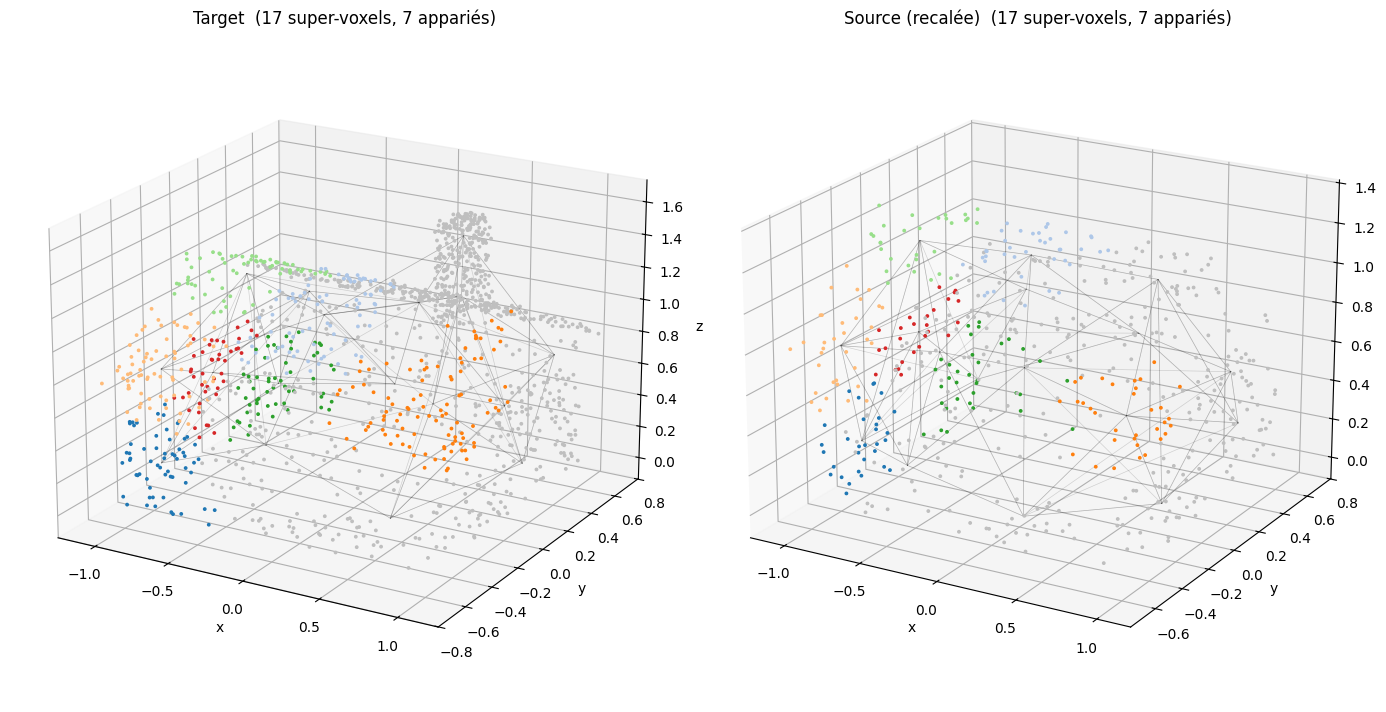

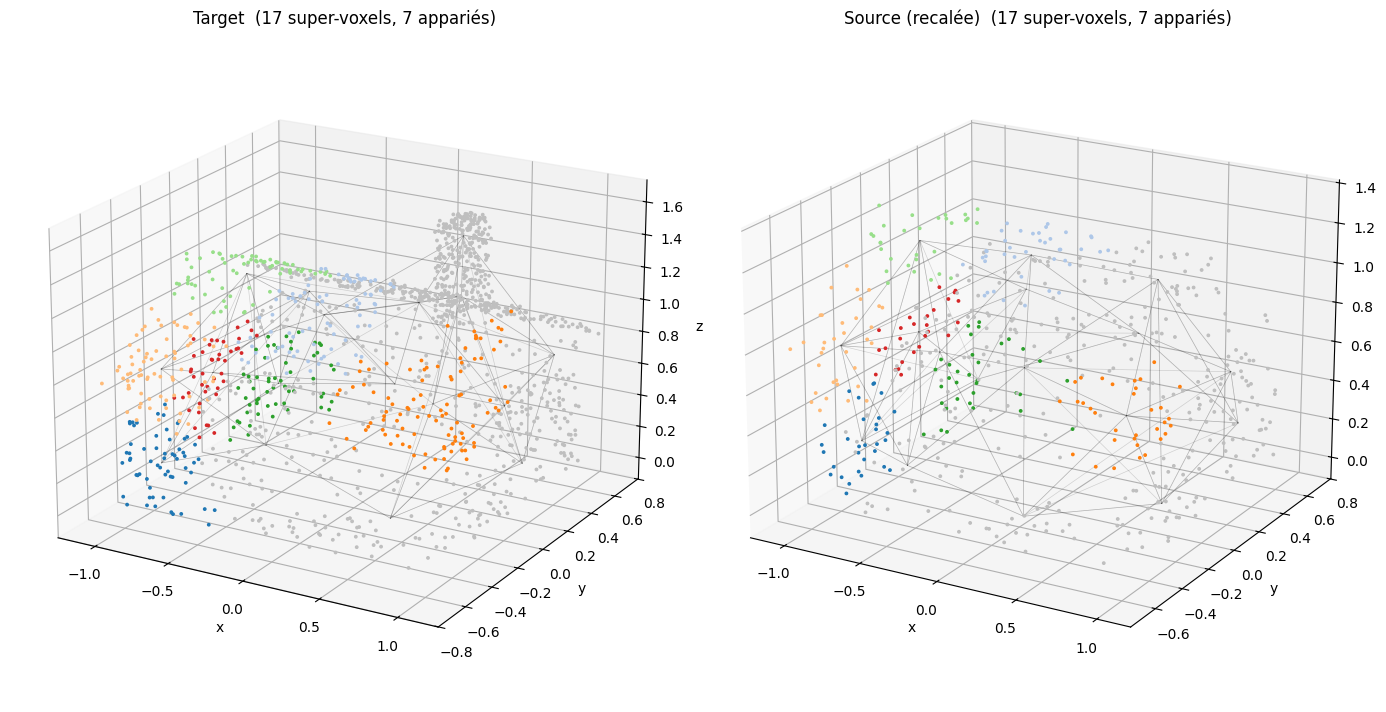

In [2]:
# ----------------------------------------------------------------------------
# Démonstration sur données synthétiques
# ----------------------------------------------------------------------------

rng = np.random.default_rng(42)

# Nuage cible : la scène "maison" structurée
target = generate_house_point_cloud(n_points=1500, seed=42)
target += rng.normal(0, 0.008, target.shape)

# Nuage source : version cross-source = sous-échantillonnée, à échelle et
# pose différentes, avec des données manquantes (simulateur du papier)
keep = rng.choice(len(target), size=int(len(target) * 0.6), replace=False)
source_raw = target[keep].copy()

# données manquantes : on retire un pan de toit entier (occlusion typique
# d'un capteur qui ne "voit" pas certaines faces)
missing_mask = ~((source_raw[:, 1] > 0.1) & (source_raw[:, 2] > 0.85))
source_raw = source_raw[missing_mask]

scale_gt = 1
angle = np.deg2rad(40)
Rz = np.array([
        [np.cos(angle), -np.sin(angle), 0],
        [np.sin(angle), np.cos(angle), 0],
        [0, 0, 1],
    ])
t_gt = np.array([5.0, -2.0, 1.0])
source = (source_raw @ Rz.T) * scale_gt + t_gt
source += rng.normal(0, 0.02 * scale_gt, source.shape)

print("Registration cross-source en cours...")
result = register_cross_source(source, target, voxel_radius_ratio=0.22)

print("\nMatrice de transformation estimée (source -> target) :")
print(result["transformation"])
print(f"\nEchelle estimée à l'étape 1 : {result['scale']:.3f} "
          f"(échelle réelle inverse ~ {1/scale_gt:.3f})")

# Erreur résiduelle moyenne au plus proche voisin (sans Open3D : cKDTree)
tree = cKDTree(target)
dists, _ = tree.query(result["source_transformed"], k=1)
radius_target = np.max(np.linalg.norm(target - target.mean(0), axis=1))
print(f"\nDistance moyenne au plus proche voisin après recalage : {dists.mean():.4f} "
          f"({100 * dists.mean() / radius_target:.1f}% du rayon de l'objet)")

    # Sauvegarde des nuages pour inspection visuelle (formats texte simples,

    # ouvrables avec numpy.loadtxt, CloudCompare, MeshLab, etc. — pas besoin
    # d'Open3D)
np.savetxt("/tmp/target.xyz", target)
np.savetxt("/tmp/source_transformed.xyz", result["source_transformed"])
print("Nuages sauvegardés dans /tmp/target.xyz et /tmp/source_transformed.xyz")

    # --- Visualisation des super-voxels appariés (même couleur = paire) ---
visualize_supervoxels(
        graph_target=result["graph_target"],
        graph_source=result["graph_source"],
        target_points=target,
        source_points=result["source_transformed"],  # repère de la cible
        correspondences=result["correspondences"],
        show_edges=True,
        title_target="Target",
        title_source="Source (recalée)",
        save_path="/tmp/supervoxel_matching.png",
        source_transform=result["transformation"],  # aligne les arêtes du graphe source
    )

# Test Sphere arm

In [4]:
rng = np.random.default_rng(42)

# Nuage cible : sphère bruitée + un "bras" pour casser la symétrie
n_pts = 800
phi = rng.uniform(0, np.pi, n_pts)
theta = rng.uniform(0, 2 * np.pi, n_pts)
target = np.stack([
        np.sin(phi) * np.cos(theta),
        np.sin(phi) * np.sin(theta),
        np.cos(phi),
    ], axis=1)
arm = rng.uniform(0, 1, (150, 3)) * [0.15, 0.15, 1.5] + [0.9, 0.0, 0.0]
target = np.vstack([target, arm]) + rng.normal(0, 0.01, (n_pts + 150, 3))

# Nuage source : version cross-source = sous-échantillonnée, à échelle et
    # pose différentes, avec des données manquantes (simulateur du papier)
keep = rng.choice(len(target), size=int(len(target) * 0.6), replace=False)
source_raw = target[keep].copy()

scale_gt = 1
angle = np.deg2rad(40)
Rz = np.array([
        [np.cos(angle), -np.sin(angle), 0],
        [np.sin(angle), np.cos(angle), 0],
        [0, 0, 1],
    ])
t_gt = np.array([5.0, -2.0, 1.0])
source = (source_raw @ Rz.T) * scale_gt + t_gt
source += rng.normal(0, 0.02 * scale_gt, source.shape)

# Test Nuclei

In [8]:
fichier = "nuclei.csv"


data_np = np.genfromtxt(fichier, delimiter=",", skip_header=1,usecols=range(1, 4))

print(data_np[:5])  # Affiche les 5 premières lignes


rng = np.random.default_rng(42)

target=data_np

target += rng.normal(0, 0.008, target.shape)

# Nuage source : version cross-source = sous-échantillonnée, à échelle et
    # pose différentes, avec des données manquantes (simulateur du papier)
keep = rng.choice(len(target), size=int(len(target) * 0.6), replace=False)
source_raw = target[keep].copy()

scale_gt = 1
angle = np.deg2rad(40)
Rz = np.array([
        [np.cos(angle), -np.sin(angle), 0],
        [np.sin(angle), np.cos(angle), 0],
        [0, 0, 1],
    ])
t_gt = np.array([5.0, -2.0, 1.0])
source = (source_raw @ Rz.T) * scale_gt + t_gt
source += rng.normal(0, 0.02 * scale_gt, source.shape)



[[ 8.72  3.73  7.18]
 [ 0.73  7.24 -0.25]
 [ 7.1   2.27  8.13]
 [ 3.67  2.32 -0.42]
 [ 9.16  2.61  7.32]]


# GRAPH MATCHING

Registration cross-source en cours...

Matrice de transformation estimée (source -> target) :
[[ 0.01033467  0.07883662  0.04034279  3.58971268]
 [-0.07383778  0.03009581 -0.03989715  2.13409854]
 [-0.04889514 -0.02878521  0.0687767  -0.60697411]
 [ 0.          0.          0.          1.        ]]

Echelle estimée à l'étape 1 : 1.002 (échelle réelle inverse ~ 1.000)

Distance moyenne au plus proche voisin après recalage : 0.0825 (1.0% du rayon de l'objet)
Nuages sauvegardés dans /tmp/target.xyz et /tmp/source_transformed.xyz


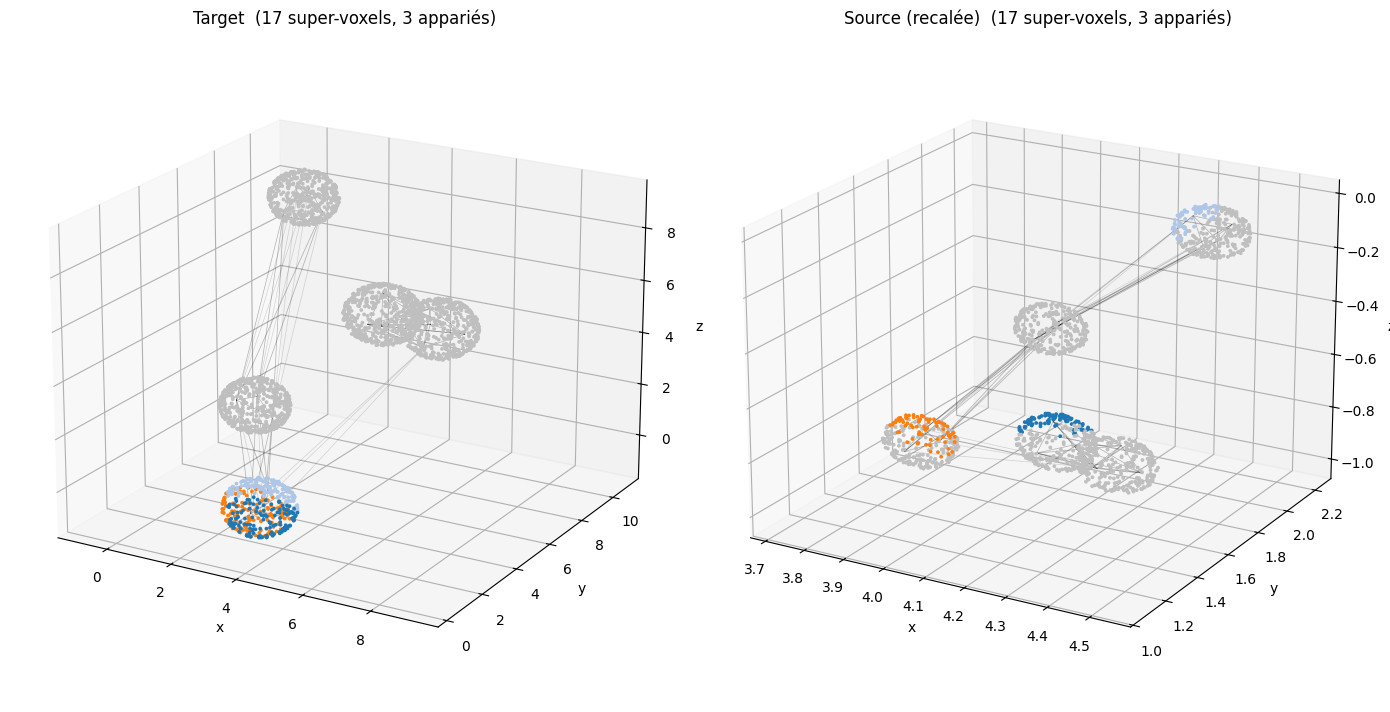

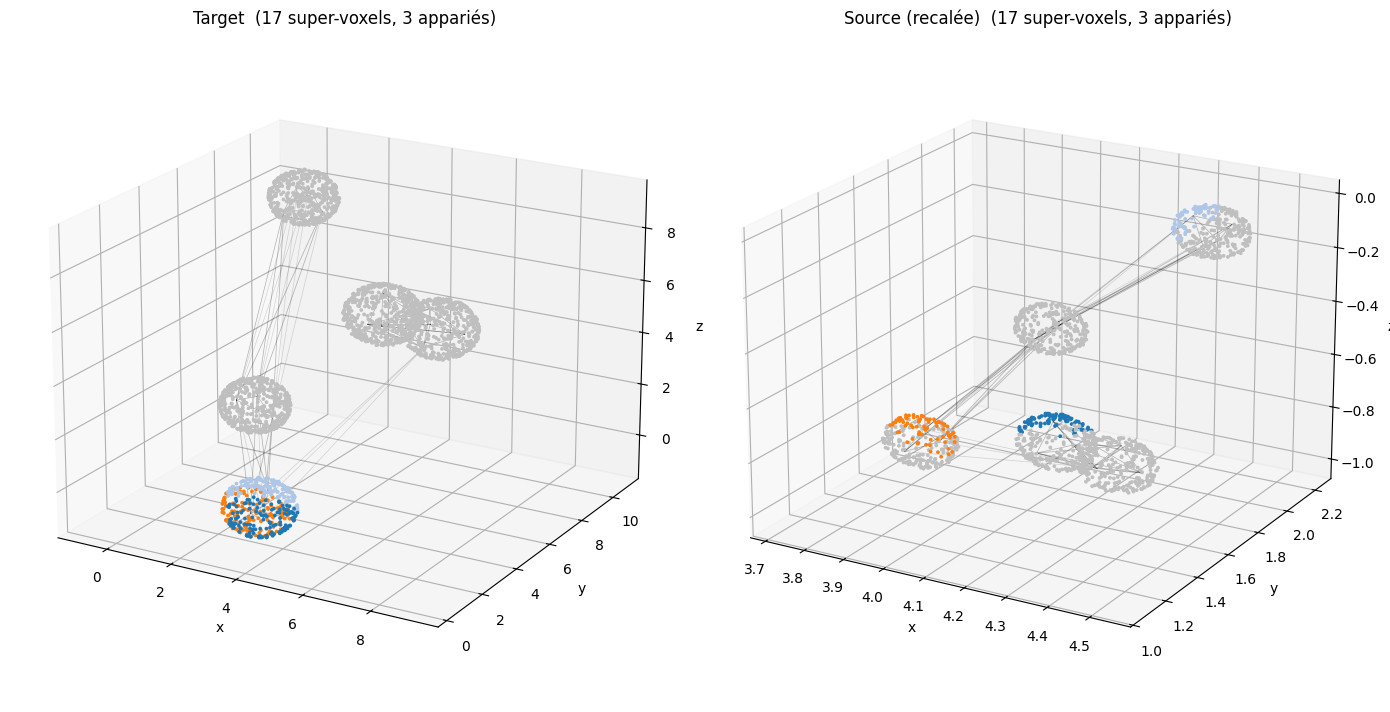

In [9]:
print("Registration cross-source en cours...")
result = register_cross_source(source, target, voxel_radius_ratio=0.22)

print("\nMatrice de transformation estimée (source -> target) :")
print(result["transformation"])
print(f"\nEchelle estimée à l'étape 1 : {result['scale']:.3f} "
          f"(échelle réelle inverse ~ {1/scale_gt:.3f})")

# Erreur résiduelle moyenne au plus proche voisin (sans Open3D : cKDTree)
tree = cKDTree(target)
dists, _ = tree.query(result["source_transformed"], k=1)
radius_target = np.max(np.linalg.norm(target - target.mean(0), axis=1))
print(f"\nDistance moyenne au plus proche voisin après recalage : {dists.mean():.4f} "
          f"({100 * dists.mean() / radius_target:.1f}% du rayon de l'objet)")

    # Sauvegarde des nuages pour inspection visuelle (formats texte simples,

    # ouvrables avec numpy.loadtxt, CloudCompare, MeshLab, etc. — pas besoin
    # d'Open3D)
np.savetxt("/tmp/target.xyz", target)
np.savetxt("/tmp/source_transformed.xyz", result["source_transformed"])
print("Nuages sauvegardés dans /tmp/target.xyz et /tmp/source_transformed.xyz")

    # --- Visualisation des super-voxels appariés (même couleur = paire) ---
visualize_supervoxels(
        graph_target=result["graph_target"],
        graph_source=result["graph_source"],
        target_points=target,
        source_points=result["source_transformed"],  # repère de la cible
        correspondences=result["correspondences"],
        show_edges=True,
        title_target="Target",
        title_source="Source (recalée)",
        save_path="/tmp/supervoxel_matching.png",
        source_transform=result["transformation"],  # aligne les arêtes du graphe source
    )

#Visualisation points clouds

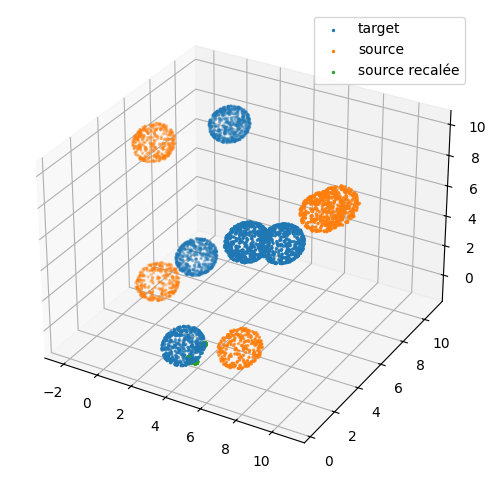

In [10]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(*target.T, s=2, label="target")
ax.scatter(*source.T, s=2, label="source")
ax.scatter(*result["source_transformed"].T, s=2, label="source recalée")
ax.legend()
plt.show()